# Aegis-40 — Neutronic Design and Analysis of a Soluble-Boron-Free Integral PWR

**TEKNOFEST 2026 — Fuel & Reactor (FER) Digital Appendix · OpenMC 0.15.3 · ENDF/B-VIII.0**

This notebook presents the full neutronic design and analysis of **Aegis-40**, a **125 MWth / 40 MWe
soluble-boron-free (SBF) integral pressurised-water reactor**. The core is a **37-assembly, 7-wide
octagonal array** of standard 17x17 Westinghouse fuel assemblies with a 200 cm active height. Reactivity
is held down without soluble boron by an **integral Gd2O3 + Er2O3 burnable-absorber** system with
**radial (ring) Gd zoning** for power flattening and **intra-assembly enrichment grading** (<= 4.95% LEU)
in place of the boron radial shaping used by boronated peers. All analyses are performed with **OpenMC**
3-D Monte-Carlo transport and depletion on **ENDF/B-VIII.0** data, from the **initial (BOC) through the
equilibrium cycle**: criticality, neutron-flux and burnup distributions, reactivity feedback coefficients,
control-rod worth and shutdown margin, and power-peaking factors. Material selection, core geometry, the
safety-criteria compliance argument, and a reproducible digital appendix are documented in the sections
below. The companion biological-shield model is included as Section 13.

## 0 · How to run this notebook (any computer) + speed tricks

This notebook is **self-contained and portable**. It reads its data-library paths,
thread count and Monte-Carlo statistics from **environment variables**, so the same
file runs unchanged on a laptop (quick check) or a workstation (reported STAT_FINAL).

### 0.1 Prerequisites
- `conda` env with **OpenMC ≥ 0.15.3** + `openmc.deplete`, `numpy`, `matplotlib`, `pyyaml`.
- ENDF/B-VIII.0 HDF5 cross-section library + a PWR depletion chain
  (`chain_endfb80_pwr.xml`).

### 0.2 Speed trick #1 — put the cross sections on a *native* disk (the "ext4 trick")
On WSL/Windows, reading the XS library across the `/mnt/d` (9p) bridge is the #1
bottleneck. **Copy it once to the Linux-native filesystem** and point OpenMC there —
this alone gives a large I/O speedup at model-build and every depletion substep:
```bash
mkdir -p ~/openmc_data
cp -r /mnt/d/openmc_data/endfb-viii.0-hdf5 ~/openmc_data/
cp    /mnt/d/openmc_data/chain_endfb80_pwr.xml ~/openmc_data/
```

### 0.3 Speed trick #2 — threads = physical cores
OpenMC scales with OpenMP threads. Set `OPENMC_THREADS` to the machine's physical
core count (e.g. 8 on the laptop, 32+ on Laziz's workstation).

### 0.4 Speed trick #3 — the STAT ladder (cell 1)
Three Monte-Carlo profiles are predefined. Use the *smallest* that answers the
question; the per-pin F_q **max** needs many histories/pin, so quote only MEDIUM+:
| Profile | batches × particles | use |
|---|---|---|
| `STAT_FAST`   | 80 × 5 000   | smoke / geometry debug (F_q noise-inflated) |
| `STAT_MEDIUM` | 180 × 20 000 | reliable static k, F_q, feedback |
| `STAT_FINAL`  | 400 × 50 000 | **reported** numbers + full depletion |

### 0.5 Launch — set the knobs, then run all cells
```bash
conda activate <your-openmc-env>
export OPENMC_CROSS_SECTIONS=$HOME/openmc_data/endfb-viii.0-hdf5/cross_sections.xml
export OPENMC_CHAIN_FILE=$HOME/openmc_data/chain_endfb80_pwr.xml
export OPENMC_THREADS=<physical cores>     # e.g. 32
jupyter nbconvert --to notebook --execute --inplace aegis40_neutronics_FER.ipynb \
        --ExecutePreprocessor.timeout=-1
```
For the **reported run**, set `STAT = STAT_FINAL` in cell 1 (it is the default).
All outputs (statepoints, JSON, plots, consolidated safety file) land in
`./aegis40_neutronics_outputs/`.

### 0.6 Approximate wall-clock (per the validating runs)
- Static suite (k, MTC/DTC, rod worth, F_q): minutes each at STAT_FAST; ~5 min/run
  at STAT_MEDIUM (8 threads).
- Depletion BOC→equilibrium: the heavy item — run at STAT_FINAL on the workstation.
- **Keep the machine awake** (disable sleep): a suspended run freezes mid-eigenvalue.


## 1 · Introduction and design objectives
Aegis-40 targets a transportable, factory-fuelled iPWR for distributed power and cogeneration in Turkiye.
The defining choice is **soluble-boron-free (SBF) operation**: no boric acid in the coolant, which gives a
strongly negative moderator coefficient, removes boron-dilution accident sequences, and simplifies the
chemistry and volume-control system. The price is that **all excess reactivity and radial power shaping
must come from solid, in-core devices** — burnable absorbers, enrichment zoning, and control rods —
rather than from boron.

**Design objectives (neutronics).**
- Reactivity-limited cycle with a small burn-up swing using integral Gd + Er burnable absorbers.
- Negative reactivity feedback at all conditions (moderator, Doppler, void).
- Adequate shutdown margin with the most-reactive rod stuck out.
- Power-peaking compatible with thermal-hydraulic (DNBR) margin at low core power density.
- Discharge burn-up in the high-burn-up LEU range at a multi-batch reload.
- Maximum enrichment within the 4.95 wt% LEU limit.

## 2 · Codes, libraries and computational methods
- **Transport / depletion:** OpenMC 0.15.3 (continuous-energy Monte-Carlo), `PredictorIntegrator` depletion.
- **Nuclear data:** ENDF/B-VIII.0 (IAEA/NNDC-hosted), with S(alpha,beta) thermal scattering for H in H2O.
- **Model fidelity:** explicit 3-D heterogeneous core — every fuel/Gd/Er rod, guide tube and instrument
  tube is modelled; vacuum boundaries on all six faces give physical radial and axial leakage.
- **Reproducibility:** every analysis exports its OpenMC XML input to `aegis40_*_outputs/0?_*/`; the
  cross-section and depletion-chain paths are set in the cell below and overridable by environment
  variables. Statistics are controlled by the `STAT_*` profiles (`STAT_FINAL` for reported numbers).

Cross-section library and depletion-chain paths (override with `OPENMC_CROSS_SECTIONS` / `OPENMC_CHAIN_FILE`):

In [1]:
import os, sys, math, time, json
from pathlib import Path
from datetime import datetime

import numpy as np
import yaml

import openmc
import openmc.deplete

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
%matplotlib inline

# ── Threads ──────────────────────────────────────────────────────────────
THREADS = int(os.environ.get("OPENMC_THREADS", "6"))
os.environ["OMP_NUM_THREADS"] = str(THREADS)

# ── Data library paths ───────────────────────────────────────────────────
XS = Path(os.environ.get(
    "OPENMC_CROSS_SECTIONS",
    "/mnt/d/openmc_data/endfb-viii.0-hdf5/cross_sections.xml"))
CHAIN = Path(os.environ.get(
    "OPENMC_CHAIN_FILE",
    "/mnt/d/openmc_data/chain_endfb80_pwr.xml"))

if not XS.is_file():
    raise FileNotFoundError(
        f"Cross-section file not found: {XS}\nSet OPENMC_CROSS_SECTIONS.")
if not CHAIN.is_file():
    raise FileNotFoundError(
        f"Depletion chain not found: {CHAIN}\nSet OPENMC_CHAIN_FILE.")

os.environ["OPENMC_CROSS_SECTIONS"] = str(XS)
os.environ["OPENMC_CHAIN_FILE"]     = str(CHAIN)
openmc.config["cross_sections"]     = str(XS)
openmc.config["chain_file"]         = str(CHAIN)

# ── Output tree ──────────────────────────────────────────────────────────
DESIGN = "hybrid"   # "hybrid" = Gd₂O₃ + Er₂O₃
ROOT  = Path("./aegis40_neutronics_outputs").resolve()
ROOT.mkdir(parents=True, exist_ok=True)
PLOTS = ROOT / "plots"; PLOTS.mkdir(exist_ok=True)

print("=" * 60)
print("Aegis-40 OpenMC — 3D CORE notebook")
print(f"  XS:      {XS}")
print(f"  Chain:   {CHAIN}")
print(f"  Threads: {THREADS}")
print(f"  Design:  {DESIGN}")
print(f"  Output:  {ROOT}")
print(f"  OpenMC:  {openmc.__version__}")
print("=" * 60)


Aegis-40 OpenMC — 3D CORE notebook
  XS:      /mnt/d/openmc_data/endfb-viii.0-hdf5/cross_sections.xml
  Chain:   /mnt/d/openmc_data/chain_endfb80_pwr.xml
  Threads: 6
  Design:  hybrid
  Output:  /mnt/d/conda-envs/openmc-py311/SMRs/Shielding/aegis40_neutronics_outputs
  OpenMC:  0.15.3


## 3 · Design criteria and standards compliance
The neutronic acceptance criteria and the standards they derive from are listed below; pass/fail against
these is evaluated in Section 10 and written to `safety_analysis_results.yaml`.

| Parameter | Criterion | Basis (standard) |
|---|---|---|
| Max fuel enrichment | <= 5.0 wt% U-235 | LEU limit (IAEA INFCIRC/254; 10 CFR 50) |
| Moderator temp. coeff. (MTC) | < 0 at power | IAEA SSR-2/1 Req. 45; NUREG-1431 LCO 3.1.3 |
| Doppler (fuel temp.) coeff. | < 0 | IAEA SSR-2/1 Req. 45 |
| Void coefficient | < 0 | IAEA SSR-2/1 Req. 45 |
| Shutdown margin (1 stuck rod) | >= 1% dk/k | NUREG-1431 LCO 3.1.1; IAEA SSR-2/1 Req. 46 |
| Diverse shutdown means | >= 2 independent | IAEA SSR-2/1 Req. 46 |
| Enthalpy-rise factor F-dH | report vs DNBR limit | NUREG-1431 LCO 3.2.2 |
| Heat-flux factor F-Q | report vs LHR/LOCA limit | NUREG-1431 LCO 3.2.1 |
| Max reactivity insertion rate | <= 7.5e-4 dk/k/s | RG 1.77 / CRDM design |

**Soluble-boron-free justification.** Boron-free operation is consistent with SSR-2/1 Req. 45 (inherently
negative feedback) and is demonstrated by the integral PWR peer **CAREM-25** (Gd burnable absorber, no
soluble boron). The methodology mirrors **microURANUS** (UNIST, 2021): unit-cell -> reflector ->
whole-core optimisation with high-fidelity Monte-Carlo verification.

In [2]:
# ============================================================================
# Aegis-40 — locked neutronic design constants
# ============================================================================

# Fuel rod / lattice geometry — Westinghouse 17x17 (FIXED: defines the T-H mesh)
N_PIN         = 17
PIN_PITCH     = 1.2623     # cm
FA_PITCH      = 21.6038    # cm
FUEL_RADIUS   = 0.40958    # cm   pellet
CLAD_INNER_R  = 0.41873    # cm
CLAD_OUTER_R  = 0.47600    # cm   Zircaloy-4
ACTIVE_HEIGHT = 200.0      # cm

# Core layout — 37 FA, 7-wide octagonal (rows 3-5-7-7-7-5-3)
N_CORE        = 7
CORE_MAP = np.array([
    [0, 0, 1, 1, 1, 0, 0],
    [0, 1, 1, 1, 1, 1, 0],
    [1, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1, 1, 1],
    [0, 1, 1, 1, 1, 1, 0],
    [0, 0, 1, 1, 1, 0, 0],
])
N_FA_TOTAL = int(CORE_MAP.sum())          # 37

# Control-rod-cluster assemblies — 12 CRAs (checkerboard; central FA = instrument)
CR_MAP = np.array([
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 1, 0, 1, 0, 0],
    [0, 1, 0, 1, 0, 1, 0],
    [0, 0, 1, 0, 1, 0, 0],
    [0, 1, 0, 1, 0, 1, 0],
    [0, 0, 1, 0, 1, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
])
N_CR_CLUSTERS = int(CR_MAP.sum())         # 12

# Reflector / plena — 20 cm radial water reflector, 30 cm axial water plena, vacuum BCs
RADIAL_REFLECTOR_CM   = 20.0
AXIAL_REFLECTOR_CM    = 30.0
RADIAL_REFLECTOR_MODE = "water"           # "water" | "steel" (heavy reflector option)

# Enrichment — 3-zone intra-assembly radial grade (centre-hot / edge-cool), <= 4.95% LEU
ENRICH_INNER  = 4.95       # wt% U-235, assembly centre
ENRICH_MID    = 4.70
ENRICH_OUTER  = 4.40       # zone grade; true core-avg computed in cell 27
ZONE_R1_CM    = 4.5
ZONE_R2_CM    = 8.5
EDGE_PIN_GRADING = True     # de-rate the FA-perimeter pin ring (boron-free de-peaking)
EDGE_ENRICH      = 3.6     # LOCKED: sharper FA-perimeter de-rate (de-peak)
RADIAL_ENRICH_ZONING = True               # LOCKED: discrete uniform-enrichment assemblies (Approach B)
RING_ENRICH = {0: 4.95, 1: 4.7, 2: 4.4, 3: 4.0}   # LOCKED in-out: high centre (Gd-suppressed) / low periphery

# Burnable absorber — integral Gd2O3 + light Er2O3 (soluble-boron-free hold-down)
GD_WT_PCT       = 6        # wt% Gd2O3 in the Gd-bearing rods (LOCKED)
N_GD_RODS       = 20       # per-FA average, ring-zoned (LOCKED; was 32 -> over-loaded keff)
GD_AXIAL_CUT_CM = 10.0     # plain-UO2 Gd cutback at each rod end
RADIAL_GD_ZONING = True     # heavier-centre Gd flattens radial power (replaces boron shaping)
GD_RING_WEIGHTS  = {0: 1.65, 1: 1.45, 2: 0.95, 3: 0.68}   # rings 1/8/16/12; core-avg ~1.0
AXIAL_BLANKET_CM     = 0.0  # optional reduced-enrichment axial blanket (0 = off)
AXIAL_BLANKET_ENRICH = 2.5
if DESIGN == "hybrid":
    ER_WT_PCT = 0.5        # light Er hold-down through mid/late cycle + cold SDM
    N_ER_RODS = 16
else:
    ER_WT_PCT = 0.0
    N_ER_RODS = 0

# Optional WABA B4C guide-tube rods (solid, SBF-compatible) — off in the locked design
WABA_ENABLE  = False
WABA_RINGS   = (2,)
WABA_B4C_WT  = 12.0
WABA_R_IN    = 0.286
WABA_R_OUT   = 0.404

# Material densities (g/cm3)
RHO_UO2 = 10.40; RHO_GD2O3 = 7.41; RHO_ER2O3 = 8.64
RHO_ZIRC = 6.55; RHO_HE = 0.0001786; RHO_B4C = 2.52

# Primary operating conditions (FER section 8.4 design basis: 12.8 MPa, Tavg 283 C)
T_FUEL_K      = 900.0
T_MOD_K       = 556.0      # core-average moderator, 283 C @ 12.8 MPa
RHO_WATER_NOM = 0.748      # g/cm3, IAPWS-IF97 @ 556 K, 12.8 MPa

# Core power / fuel cycle
CORE_POWER_MWT = 125.0
HM_MASS_T      = 9.87       # 37 FA
SPECIFIC_POWER = CORE_POWER_MWT / HM_MASS_T
N_BATCHES      = 4

# Monte Carlo statistics (bump to STAT_FINAL for reported numbers)
STAT_FAST   = dict(batches=80,  inactive=25, particles=5000)
STAT_MEDIUM = dict(batches=180, inactive=50, particles=20000)
STAT_FINAL  = dict(batches=400, inactive=80, particles=50000)
STAT = STAT_MEDIUM

_enr_avg = (ENRICH_INNER + 2*ENRICH_MID + ENRICH_OUTER) / 4.0
print(f"Core: {N_FA_TOTAL} FA (7-wide octagon) | {N_CR_CLUSTERS} control-rod clusters")
print(f"Enrichment {ENRICH_INNER}/{ENRICH_MID}/{ENRICH_OUTER} wt% (zone-avg ~{_enr_avg:.2f}, excl. edge/BA) | Gd2O3 {GD_WT_PCT} wt%x{N_GD_RODS} + Er2O3 {ER_WT_PCT} wt%x{N_ER_RODS}")
print(f"Power {CORE_POWER_MWT} MWth | HM {HM_MASS_T} t | specific power {SPECIFIC_POWER:.2f} W/gHM | {N_BATCHES}-batch")
print(f"Coolant/moderator 12.8 MPa, T_mod {T_MOD_K} K, rho {RHO_WATER_NOM} g/cm3 | MC {STAT}")

Core: 37 FA (7-wide octagon) | 12 control-rod clusters
Enrichment 4.95/4.7/4.4 wt% (zone-avg ~4.69, excl. edge/BA) | Gd2O3 6 wt%x20 + Er2O3 0.5 wt%x16
Power 125.0 MWth | HM 9.87 t | specific power 12.66 W/gHM | 4-batch
Coolant/moderator 12.8 MPa, T_mod 556.0 K, rho 0.748 g/cm3 | MC {'batches': 180, 'inactive': 50, 'particles': 20000}


## 4 · Core materials and selection criteria
All material compositions are built in the factory functions in the next cell; their selection rationale
and behaviour in the neutron and temperature environment are summarised here.

| Component | Material | Density (g/cm3) | Why selected | In-core behaviour (irradiation / temperature) |
|---|---|---|---|---|
| Fuel | UO2, 4.40-4.95 wt% LEU, zoned | 10.40 | Proven LWR fuel; high melting point; established licensing basis | Doppler broadening of U-238 gives prompt negative feedback; fission-gas release & swelling bounded at design LHR; T_fuel ~900 K nominal |
| Burnable absorber | Gd2O3 (8 wt%) in UO2 | 10.4 mix | Strong thermal absorber; burns out ~10 GWd/t to control BOC excess in SBF core | Gd-155/157 deplete early -> reactivity rises smoothly (no residual penalty at the chosen loading) |
| Burnable absorber | Er2O3 (0.5 wt%) in UO2 | 10.4 mix | Slowly-depleting absorber; flattens mid/late-cycle reactivity, aids cold shutdown | Er-167 resonance gives a slightly more negative MTC; depletes gradually across the cycle |
| Cladding | Zircaloy-4 | 6.55 | Low thermal-neutron absorption; corrosion & creep performance to high burn-up | Low parasitic capture; hydriding/oxidation bounded within design temperature & fluence |
| Coolant / moderator | Light water, 12.8 MPa, 283 C | 0.748 | Excellent moderator; SBF (no boric acid) for strong negative MTC | Density feedback -> negative MTC and void coefficient; S(alpha,beta) thermal scattering modelled |
| Reflector | Light water, 20 cm radial + 30 cm axial plena | 0.748 | High thermal albedo flattens peripheral power and reduces leakage in a compact core | Returns thermal neutrons to edge pins; no activation concern |
| Control rods | B4C | 2.52 | Standard strong absorber for rod worth & scram | B-10 depletes slowly over life; He production bounded; gives the diverse, fast-acting shutdown means |
| Guide / instrument tubes | Zircaloy-4 + water | - | Standard 17x17 internals; water holes for rodding & instrumentation | Local thermal-flux peaking at water holes managed by enrichment grading / Gd placement |

Operating-temperature set: fuel T ~ 900 K, moderator T ~ 556 K (12.8 MPa). Transient/accident temperature
behaviour (Doppler, MTC, void) is quantified by the reactivity-coefficient analyses in Section 7.

In [3]:
# ============================================================================
# Material factories
# ============================================================================

def mat_uo2(enrichment, temp=T_FUEL_K, name=None):
    m = openmc.Material(name=name or f"UO2_{enrichment:.2f}pct", temperature=temp)
    m.set_density("g/cm3", RHO_UO2)
    m.add_element("U", 1.0, enrichment=enrichment)
    m.add_element("O", 2.0)
    m.depletable = True
    return m


def _mixed_fuel(base_enrich, gd_wt=0.0, er_wt=0.0, temp=T_FUEL_K, name="fuel"):
    uo2_frac = 1.0 - (gd_wt + er_wt) / 100.0
    components, fracs = [], []
    uo2 = mat_uo2(base_enrich, temp=temp, name=f"{name}_uo2")
    components.append(uo2); fracs.append(uo2_frac)
    if gd_wt > 0:
        m = openmc.Material(name=f"{name}_gd2o3", temperature=temp)
        m.set_density("g/cm3", RHO_GD2O3)
        m.add_element("Gd", 2.0); m.add_element("O", 3.0)
        components.append(m); fracs.append(gd_wt / 100.0)
    if er_wt > 0:
        m = openmc.Material(name=f"{name}_er2o3", temperature=temp)
        m.set_density("g/cm3", RHO_ER2O3)
        m.add_element("Er", 2.0); m.add_element("O", 3.0)
        components.append(m); fracs.append(er_wt / 100.0)
    mixed = openmc.Material.mix_materials(components, fracs,
                                          percent_type="wo", name=name)
    mixed.temperature = temp
    mixed.depletable = True
    return mixed


def mat_water(temp=T_MOD_K, density=RHO_WATER_NOM, name="H2O"):
    m = openmc.Material(name=name, temperature=temp)
    m.set_density("g/cm3", density)
    m.add_element("H", 2.0); m.add_element("O", 1.0)
    m.add_s_alpha_beta("c_H_in_H2O")
    return m


def mat_zircaloy(temp=600.0):
    m = openmc.Material(name="Zircaloy-4", temperature=temp)
    m.set_density("g/cm3", RHO_ZIRC)
    m.add_element("Zr", 0.9823, percent_type="wo")
    m.add_element("Sn", 0.0145, percent_type="wo")
    m.add_element("Fe", 0.0021, percent_type="wo")
    m.add_element("Cr", 0.0011, percent_type="wo")
    return m


def mat_helium(temp=T_FUEL_K):
    m = openmc.Material(name="He gap", temperature=temp)
    m.set_density("g/cm3", RHO_HE)
    m.add_element("He", 1.0)
    return m


def mat_b4c(temp=600.0):
    m = openmc.Material(name="B4C", temperature=temp)
    m.set_density("g/cm3", RHO_B4C)
    m.add_element("B", 4.0)
    m.add_element("C", 1.0)
    return m


def mat_waba(b4c_wt=None, temp=T_MOD_K, name="WABA_B4C_Al2O3"):
    """WABA absorber annulus: B4C dispersed in an Al2O3 matrix — a SOLID burnable
       poison (not soluble boron). Depletable so B-10 burns out like a real WABA."""
    if b4c_wt is None:
        b4c_wt = WABA_B4C_WT
    al2o3 = openmc.Material(name="Al2O3", temperature=temp)
    al2o3.set_density("g/cm3", 3.97)
    al2o3.add_element("Al", 2.0); al2o3.add_element("O", 3.0)
    m = openmc.Material.mix_materials([mat_b4c(temp=temp), al2o3],
                                      [b4c_wt / 100.0, 1.0 - b4c_wt / 100.0],
                                      percent_type="wo", name=name)
    m.temperature = temp
    m.depletable = True
    return m


## 5 · Core geometry and layout
Standard 17x17 lattice: **264 fuel rods, 24 guide tubes, 1 central instrument tube** per assembly. The
37-assembly core is a 7-wide octagon (rows 3-5-7-7-7-5-3); control-rod clusters occupy 12 assemblies in a
checkerboard pattern with the central assembly reserved for instrumentation. Gd and Er rods are placed in
8-fold-symmetric groups (Gd biased to mid-radius, Er to the outer ring); Gd loading is zoned by core ring
(heavier at the centre) to flatten radial power without soluble boron. Pin dimensions, pitch and active
height are fixed (Section 4 table / config cell) so the thermal-hydraulic model is unaffected.

In [4]:
# ── Intra-FA pin map ────────────────────────────────────────────────────
CENTER_IDX     = (N_PIN - 1) // 2
INSTRUMENT_POS = (CENTER_IDX, CENTER_IDX)

GUIDE_ALL = [
    (5,2),(8,2),(11,2),(3,3),(13,3),
    (2,5),(5,5),(8,5),(11,5),(14,5),
    (5,8),(8,8),(11,8),(2,8),(14,8),
    (2,11),(5,11),(8,11),(11,11),(14,11),
    (3,13),(13,13),(5,14),(8,14),(11,14),
]
GUIDE_POS = [p for p in GUIDE_ALL if p != INSTRUMENT_POS]              # 24 guides
FUEL_POS  = [(i,j) for j in range(N_PIN) for i in range(N_PIN)
             if (i,j) not in set(GUIDE_ALL)]                           # 264 fuel pins
assert len(FUEL_POS) == 264 and len(GUIDE_POS) == 24


def _pin_radius(i, j):
    cx = (N_PIN - 1) / 2.0
    return math.hypot((i - cx) * PIN_PITCH, (j - cx) * PIN_PITCH)


def _enrichment_for_pin(i, j):
    # Outermost pin ring (FA perimeter) faces the inter-assembly water gaps, where
    # thermal flux — and hence per-pin power — peaks: the main driver of F_ΔH.
    # Give that ring its own, lower enrichment when EDGE_PIN_GRADING is on.
    if EDGE_PIN_GRADING and (i in (0, N_PIN - 1) or j in (0, N_PIN - 1)):
        return EDGE_ENRICH
    r = _pin_radius(i, j)
    if r < ZONE_R1_CM:   return ENRICH_INNER
    if r < ZONE_R2_CM:   return ENRICH_MID
    return ENRICH_OUTER


def _symmetry_group(i, j, exclude=None):
    c = N_PIN - 1
    pts = {(i,j),(c-i,j),(i,c-j),(c-i,c-j),
           (j,i),(c-j,i),(j,c-i),(c-j,c-i)}
    ex = set(exclude or [])
    return tuple(sorted(p for p in pts if p in set(FUEL_POS) and p not in ex))


def _select_sym_positions(n, bias="mid", exclude=None):
    exclude = set(exclude or [])
    seen, groups = set(), []
    for ij in FUEL_POS:
        if ij in exclude: continue
        g = _symmetry_group(*ij, exclude=exclude)
        if not g or g in seen: continue
        seen.add(g)
        r_mean = sum(_pin_radius(*p) for p in g) / len(g)
        if   bias == "inner": score =  r_mean
        elif bias == "outer": score = -r_mean
        else:                 score = abs(r_mean - 5.2 * PIN_PITCH)
        groups.append((score, g))
    chosen = []
    for _, g in sorted(groups):
        if len(chosen) + len(g) <= n: chosen.extend(g)
        if len(chosen) == n: break
    return chosen[:n]


GD_POSITIONS = set(_select_sym_positions(N_GD_RODS, bias="mid"))
ER_POSITIONS = set(_select_sym_positions(N_ER_RODS, bias="outer", exclude=GD_POSITIONS))
print(f"Gd rods/FA (avg): {len(GD_POSITIONS)}  |  Er rods/FA: {len(ER_POSITIONS)}")


# ── Radial (assembly) ring helpers for Gd power-flattening ──────────
def _core_ring_of(i, j):
    """Radial ring of a core position: 0=centre, 1=inner8, 2=mid16, 3=outer12."""
    cc = (N_CORE - 1) // 2                          # centre index = 3 for 7-wide
    return min(max(abs(i - cc), abs(j - cc)), 3)    # Chebyshev distance, capped at 3

def _gd_count_for_ring(ring):
    """Per-ring Gd-rod count; uniform N_GD_RODS unless RADIAL_GD_ZONING."""
    if not RADIAL_GD_ZONING:
        return N_GD_RODS
    return int(round(N_GD_RODS * GD_RING_WEIGHTS.get(ring, 1.0)))

def _gd_positions_for_ring(ring):
    return set(_select_sym_positions(_gd_count_for_ring(ring), bias="mid"))

def _er_positions_for_ring(ring):
    gd = _gd_positions_for_ring(ring)
    return set(_select_sym_positions(N_ER_RODS, bias="outer", exclude=gd))

if RADIAL_GD_ZONING:
    print("Radial Gd zoning per ring (centre→edge): "
          + ", ".join(f"r{r}={_gd_count_for_ring(r)}" for r in (0, 1, 2, 3)))


Gd rods/FA (avg): 20  |  Er rods/FA: 16
Radial Gd zoning per ring (centre→edge): r0=33, r1=29, r2=19, r3=14


### Geometry builders (3-D core)
Pin universes are axially infinite; the active fuel is clipped at the assembly level by the active-height
planes (z = +/-100 cm). Above/below the active region (|z| in [100, 130] cm) every pin position becomes
plain water (the top/bottom plena); beyond z = +/-130 cm is vacuum (axial leakage). Radially the core
lattice is wrapped in a 20 cm water reflector and then a vacuum boundary. The shield wrapper (Section 13)
optionally replaces the reflector/vacuum with the full biological shield.

In [5]:
# ============================================================================
# Pin universe — radially structured; axial fuel bounds applied here
# ============================================================================
def _make_pin_universe(fuel_mat, water_mat, clad_mat, gap_mat,
                       name="pin", gd_cut_bot=0.0, gd_cut_top=0.0, cutback_mat=None,
                       blanket_mat=None, blanket_cm=0.0):
    """Pin universe valid for **all z**. Inside z ∈ [-H/2, +H/2] is fuel+clad+gap+moderator;
       outside (axial plena) every radial position becomes water.
       If blanket_mat/blanket_cm given, the top & bottom blanket_cm of the active
       column become reduced-enrichment blanket fuel (applies to EVERY pin and
       supersedes the Gd axial cutback). Otherwise the optional Gd axial cutback
       (plain UO₂) is applied at the top/bottom of the active region."""
    fuel_cyl = openmc.ZCylinder(r=FUEL_RADIUS)
    clad_i   = openmc.ZCylinder(r=CLAD_INNER_R)
    clad_o   = openmc.ZCylinder(r=CLAD_OUTER_R)
    zbot = openmc.ZPlane(z0=-ACTIVE_HEIGHT / 2.0)
    ztop = openmc.ZPlane(z0= ACTIVE_HEIGHT / 2.0)

    cutback_mat = cutback_mat or fuel_mat
    cells = []

    if blanket_mat is not None and blanket_cm > 0:
        # — Reduced-enrichment axial blanket at each end (all pins) —
        zbb = openmc.ZPlane(z0=-ACTIVE_HEIGHT / 2.0 + blanket_cm)
        ztb = openmc.ZPlane(z0= ACTIVE_HEIGHT / 2.0 - blanket_cm)
        cells.append(openmc.Cell(name=f"{name}_blk_bot", fill=blanket_mat,
                                 region=-fuel_cyl & +zbot & -zbb))
        cells.append(openmc.Cell(name=f"{name}_fuel", fill=fuel_mat,
                                 region=-fuel_cyl & +zbb & -ztb))
        cells.append(openmc.Cell(name=f"{name}_blk_top", fill=blanket_mat,
                                 region=-fuel_cyl & +ztb & -ztop))
    else:
        # — Active-region fuel column with optional Gd axial cutback —
        if gd_cut_bot > 0:
            zb = openmc.ZPlane(z0=-ACTIVE_HEIGHT / 2.0 + gd_cut_bot)
            cells.append(openmc.Cell(name=f"{name}_bot_cut", fill=cutback_mat,
                                     region=-fuel_cyl & +zbot & -zb))
        else:
            zb = zbot

        if gd_cut_top > 0:
            zt = openmc.ZPlane(z0= ACTIVE_HEIGHT / 2.0 - gd_cut_top)
            cells.append(openmc.Cell(name=f"{name}_fuel", fill=fuel_mat,
                                     region=-fuel_cyl & +zb & -zt))
            cells.append(openmc.Cell(name=f"{name}_top_cut", fill=cutback_mat,
                                     region=-fuel_cyl & +zt & -ztop))
        else:
            zt = ztop
            cells.append(openmc.Cell(name=f"{name}_fuel", fill=fuel_mat,
                                     region=-fuel_cyl & +zb & -zt))

    # gap + clad + moderator (only inside active region)
    cells.append(openmc.Cell(name=f"{name}_gap",  fill=gap_mat,
                             region=+fuel_cyl & -clad_i & +zbot & -ztop))
    cells.append(openmc.Cell(name=f"{name}_clad", fill=clad_mat,
                             region=+clad_i & -clad_o & +zbot & -ztop))
    cells.append(openmc.Cell(name=f"{name}_mod",  fill=water_mat,
                             region=+clad_o & +zbot & -ztop))

    # Axial water plenum (above and below active region — radially unbounded)
    cells.append(openmc.Cell(name=f"{name}_plenum_top", fill=water_mat,
                             region=+ztop))
    cells.append(openmc.Cell(name=f"{name}_plenum_bot", fill=water_mat,
                             region=-zbot))

    return openmc.Universe(name=name, cells=cells)


def _make_guide_universe(water_mat, b4c_mat=None, waba_mat=None, name="guide"):
    """Guide tube. b4c_mat → B4C control rod in active region (ARI). waba_mat →
       WABA burnable-poison annulus (water centre, B4C-Al2O3 ring, water gap).
       Neither → plain water (ARO). Axially open with water plena outside H."""
    gt_inner = openmc.ZCylinder(r=0.5624)
    gt_outer = openmc.ZCylinder(r=0.6020)
    zbot = openmc.ZPlane(z0=-ACTIVE_HEIGHT / 2.0)
    ztop = openmc.ZPlane(z0= ACTIVE_HEIGHT / 2.0)
    cells = []
    if waba_mat is not None and b4c_mat is None:
        r_in  = openmc.ZCylinder(r=WABA_R_IN)
        r_out = openmc.ZCylinder(r=WABA_R_OUT)
        cells.append(openmc.Cell(fill=water_mat, region=-r_in & +zbot & -ztop))
        cells.append(openmc.Cell(fill=waba_mat,  region=+r_in & -r_out & +zbot & -ztop))
        cells.append(openmc.Cell(fill=water_mat, region=+r_out & -gt_inner & +zbot & -ztop))
    else:
        inner_fill = b4c_mat if b4c_mat is not None else water_mat
        cells.append(openmc.Cell(fill=inner_fill, region=-gt_inner & +zbot & -ztop))
    cells.append(openmc.Cell(fill=water_mat, region=+gt_inner & -gt_outer & +zbot & -ztop))
    cells.append(openmc.Cell(fill=water_mat, region=+gt_outer & +zbot & -ztop))
    cells.append(openmc.Cell(fill=water_mat, region=+ztop))
    cells.append(openmc.Cell(fill=water_mat, region=-zbot))
    return openmc.Universe(name=name, cells=cells)


In [6]:
# ============================================================================
# Assembly universe builder
# ============================================================================
def _build_fa_universe(fuel_temp, mod_temp, water, clad, gap, b4c,
                       plain_mats, gd_mat, gd_cut_mat, er_mat,
                       insert_cr, name="FA",
                       gd_positions=None, er_positions=None, blanket_mat=None,
                       waba_mat=None, fa_enrich=None):
    """Return a Universe containing the 17×17 pin lattice inside an FA-pitch square.
       insert_cr: True → guide tubes filled with B4C (control rod inserted)
                  False → guide tubes filled with water (rod out)
       gd_positions / er_positions: per-assembly BA pin sets (default = the
       uniform/ring-average globals)."""
    if gd_positions is None: gd_positions = GD_POSITIONS
    if er_positions is None: er_positions = ER_POSITIONS

    pin_universes = {}
    for (i, j) in FUEL_POS:
        e = fa_enrich if fa_enrich is not None else _enrichment_for_pin(i, j)
        ukey = f"plain_{e:.1f}"
        if ukey not in pin_universes:
            pin_universes[ukey] = _make_pin_universe(
                plain_mats[f"UO2_{e:.1f}"], water, clad, gap, name=f"{name}_{ukey}",
                blanket_mat=blanket_mat, blanket_cm=AXIAL_BLANKET_CM)

    gd_pin_u = _make_pin_universe(gd_mat, water, clad, gap, name=f"{name}_Gd_pin",
                                  gd_cut_bot=GD_AXIAL_CUT_CM,
                                  gd_cut_top=GD_AXIAL_CUT_CM,
                                  cutback_mat=gd_cut_mat,
                                  blanket_mat=blanket_mat, blanket_cm=AXIAL_BLANKET_CM)
    pin_universes["gd"] = gd_pin_u

    er_pin_u = None
    if er_mat is not None and er_positions:
        er_pin_u = _make_pin_universe(er_mat, water, clad, gap, name=f"{name}_Er_pin",
                                      blanket_mat=blanket_mat, blanket_cm=AXIAL_BLANKET_CM)
        pin_universes["er"] = er_pin_u

    guide_aro_u = _make_guide_universe(water, b4c_mat=None,
                                       name=f"{name}_guide_aro")
    guide_ari_u = _make_guide_universe(water, b4c_mat=b4c,
                                       name=f"{name}_guide_ari")
    guide_waba_u = (_make_guide_universe(water, waba_mat=waba_mat,
                                         name=f"{name}_guide_waba")
                    if waba_mat is not None else None)
    instrument_u = guide_aro_u   # instrument tube never gets a rod

    lattice = openmc.RectLattice(name=f"{name}_pinlattice")
    lattice.pitch = (PIN_PITCH, PIN_PITCH)
    lattice.lower_left = (-N_PIN * PIN_PITCH / 2.0, -N_PIN * PIN_PITCH / 2.0)
    lattice.outer = openmc.Universe(cells=[openmc.Cell(fill=water)])

    grid = []
    for j in range(N_PIN - 1, -1, -1):
        row = []
        for i in range(N_PIN):
            pos = (i, j)
            if pos == INSTRUMENT_POS:
                row.append(instrument_u)
            elif pos in set(GUIDE_POS):
                if insert_cr:
                    row.append(guide_ari_u)
                elif guide_waba_u is not None:
                    row.append(guide_waba_u)
                else:
                    row.append(guide_aro_u)
            elif pos in gd_positions:
                row.append(gd_pin_u)
            elif pos in er_positions and er_pin_u is not None:
                row.append(er_pin_u)
            else:
                e = fa_enrich if fa_enrich is not None else _enrichment_for_pin(i, j)
                row.append(pin_universes[f"plain_{e:.1f}"])
        grid.append(row)
    lattice.universes = grid

    # FA cell: pin lattice clipped to one FA pitch (square)
    half_fa = FA_PITCH / 2.0
    xlo = openmc.XPlane(-half_fa)
    xhi = openmc.XPlane( half_fa)
    ylo = openmc.YPlane(-half_fa)
    yhi = openmc.YPlane( half_fa)
    fa_cell = openmc.Cell(name=f"{name}_cell", fill=lattice,
                          region=+xlo & -xhi & +ylo & -yhi)

    return openmc.Universe(name=f"{name}_universe", cells=[fa_cell])


def _water_assembly_universe(water, name="water_FA"):
    """Pure-water universe used for the corners of the core lattice."""
    half_fa = FA_PITCH / 2.0
    xlo = openmc.XPlane(-half_fa); xhi = openmc.XPlane(half_fa)
    ylo = openmc.YPlane(-half_fa); yhi = openmc.YPlane(half_fa)
    cell = openmc.Cell(name=f"{name}_cell", fill=water,
                       region=+xlo & -xhi & +ylo & -yhi)
    return openmc.Universe(name=name, cells=[cell])


In [7]:
# ============================================================================
# build_core — full 3D core model (this is what every analysis now uses)
# ============================================================================
def build_core(fuel_temp=T_FUEL_K, mod_temp=T_MOD_K,
               water_density=RHO_WATER_NOM,
               control_rod_state="aro",     # "aro" | "ari" | iterable of (i,j) inserted FA positions
               void_fraction=0.0,
               stats=None):
    """Build the 3D 37-FA core model with vacuum BCs on all 6 outer surfaces.
       Returns (model, mat_dict, fa_volume_info)."""
    stats = stats or STAT
    eff_density = water_density * (1.0 - void_fraction)

    water = mat_water(temp=mod_temp, density=eff_density, name="H2O_active")
    clad  = mat_zircaloy(temp=mod_temp)
    gap   = mat_helium(temp=fuel_temp)
    b4c   = mat_b4c(temp=600.0)

    # Distinct cool water for radial+axial reflector (own depletable=False)
    refl_water = mat_water(temp=mod_temp, density=RHO_WATER_NOM, name="H2O_reflector")
    # Optional SS-304 heavy reflector replacing the water radial reflector
    refl_steel = None
    if RADIAL_REFLECTOR_MODE == "steel":
        refl_steel = openmc.Material(name="SS304_reflector", temperature=mod_temp)
        refl_steel.set_density("g/cm3", 7.90)
        for _el, _f in (("Fe", .685), ("Cr", .190), ("Ni", .095),
                        ("Mn", .020), ("Si", .010)):
            refl_steel.add_element(_el, _f, "wo")
        refl_steel.depletable = False
    refl_fill = refl_steel if refl_steel is not None else refl_water

    _enr_levels = {ENRICH_INNER, ENRICH_MID, ENRICH_OUTER}
    if EDGE_PIN_GRADING: _enr_levels.add(EDGE_ENRICH)
    if RADIAL_ENRICH_ZONING: _enr_levels.update(RING_ENRICH.values())
    plain_mats = {}
    for e in sorted(_enr_levels):
        plain_mats[f"UO2_{e:.1f}"] = mat_uo2(e, temp=fuel_temp, name=f"UO2_{e:.1f}")

    gd_mat     = _mixed_fuel(ENRICH_MID, gd_wt=GD_WT_PCT, er_wt=0.0,
                             temp=fuel_temp, name="Gd_fuel")
    gd_cut_mat = mat_uo2(ENRICH_MID, temp=fuel_temp, name="Gd_cutback_UO2")
    blanket_mat = (mat_uo2(AXIAL_BLANKET_ENRICH, temp=fuel_temp, name="UO2_blanket")
                   if AXIAL_BLANKET_CM > 0 else None)
    waba_mat = mat_waba(temp=mod_temp) if WABA_ENABLE else None

    if N_ER_RODS > 0 and ER_WT_PCT > 0:
        er_mat = _mixed_fuel(ENRICH_MID, gd_wt=0.0, er_wt=ER_WT_PCT,
                             temp=fuel_temp, name="Er_fuel")
    else:
        er_mat = None

    mat_dict = {"water": water, "refl_water": refl_water, "clad": clad,
                "gap": gap, "b4c": b4c, "gd_fuel": gd_mat, "gd_cutback": gd_cut_mat}
    if blanket_mat is not None: mat_dict["blanket"] = blanket_mat
    if waba_mat is not None: mat_dict["waba"] = waba_mat
    if er_mat is not None: mat_dict["er_fuel"] = er_mat
    mat_dict.update(plain_mats)

    # Decide which FA positions have CR inserted
    if control_rod_state == "aro":
        cr_inserted_positions = set()
    elif control_rod_state == "ari":
        cr_inserted_positions = {(i, j) for j in range(N_CORE) for i in range(N_CORE)
                                 if CR_MAP[N_CORE - 1 - j, i] == 1}
    else:
        cr_inserted_positions = set(control_rod_state)

    # ── Per-ring FA universes (radial Gd zoning) ──────────────────
    # Ring 0 = centre FA, 1 = inner 8, 2 = outer 12.  Heavier Gd at the centre
    # pushes power outward.  CR clusters only live in the central 3×3 (rings 0-1),
    # so the CR-in flavour is only built for those rings.
    def _ring_ba(ring):
        if RADIAL_GD_ZONING:
            return _gd_positions_for_ring(ring), _er_positions_for_ring(ring)
        return GD_POSITIONS, ER_POSITIONS

    fa_aro_by_ring, fa_ari_by_ring = {}, {}
    for ring in (0, 1, 2, 3):
        gd, er = _ring_ba(ring)
        fa_aro_by_ring[ring] = _build_fa_universe(
            fuel_temp, mod_temp, water, clad, gap, b4c,
            plain_mats, gd_mat, gd_cut_mat, er_mat,
            insert_cr=False, name=f"FA_aro_r{ring}",
            gd_positions=gd, er_positions=er, blanket_mat=blanket_mat,
            waba_mat=(waba_mat if ring in WABA_RINGS else None),
            fa_enrich=(RING_ENRICH[ring] if RADIAL_ENRICH_ZONING else None))
    for ring in (0, 1, 2, 3):
        gd, er = _ring_ba(ring)
        fa_ari_by_ring[ring] = _build_fa_universe(
            fuel_temp, mod_temp, water, clad, gap, b4c,
            plain_mats, gd_mat, gd_cut_mat, er_mat,
            insert_cr=True, name=f"FA_ari_r{ring}",
            gd_positions=gd, er_positions=er, blanket_mat=blanket_mat,
            fa_enrich=(RING_ENRICH[ring] if RADIAL_ENRICH_ZONING else None))
    water_u = _water_assembly_universe(refl_fill, name="water_FA")

    # ── Core RectLattice (7-wide, 37 FA) ──────────────────────────────────
    core_lat = openmc.RectLattice(name="core_lattice")
    core_lat.pitch = (FA_PITCH, FA_PITCH)
    core_lat.lower_left = (-N_CORE * FA_PITCH / 2.0, -N_CORE * FA_PITCH / 2.0)
    core_lat.outer = water_u

    grid = []
    n_cr_actually_inserted = 0
    for j in range(N_CORE - 1, -1, -1):    # row 0 is bottom in OpenMC convention
        row = []
        for i in range(N_CORE):
            ij = (i, j)
            if CORE_MAP[N_CORE - 1 - j, i] == 0:
                row.append(water_u)
            else:
                ring = _core_ring_of(i, j)
                if ij in cr_inserted_positions and ring in fa_ari_by_ring:
                    row.append(fa_ari_by_ring[ring]); n_cr_actually_inserted += 1
                else:
                    row.append(fa_aro_by_ring[ring])
        grid.append(row)
    core_lat.universes = grid

    # ── Cells: core lattice → radial reflector → outer vacuum box ─────────
    core_half = N_CORE * FA_PITCH / 2.0
    outer_half = core_half + RADIAL_REFLECTOR_CM
    H = ACTIVE_HEIGHT / 2.0
    Z_OUTER = H + AXIAL_REFLECTOR_CM      # vacuum BC at ±(H + axial reflector)

    # Inner core region (lattice covers full radial extent of outer_half — pin universes
    # have their own water plena beyond active height, so axially the lattice is valid
    # everywhere in z).  We bound the lattice in a square of side = 2*core_half.
    xlo_c = openmc.XPlane(-core_half); xhi_c = openmc.XPlane(core_half)
    ylo_c = openmc.YPlane(-core_half); yhi_c = openmc.YPlane(core_half)

    # Outer vacuum box
    xlo = openmc.XPlane(-outer_half, boundary_type="vacuum")
    xhi = openmc.XPlane( outer_half, boundary_type="vacuum")
    ylo = openmc.YPlane(-outer_half, boundary_type="vacuum")
    yhi = openmc.YPlane( outer_half, boundary_type="vacuum")
    zlo = openmc.ZPlane(-Z_OUTER, boundary_type="vacuum")
    zhi = openmc.ZPlane( Z_OUTER, boundary_type="vacuum")

    core_cell = openmc.Cell(name="core_lat_cell", fill=core_lat,
                            region=+xlo_c & -xhi_c & +ylo_c & -yhi_c
                                   & +zlo & -zhi)
    refl_cell = openmc.Cell(name="radial_reflector", fill=refl_fill,
                            region=(+xlo & -xhi & +ylo & -yhi & +zlo & -zhi)
                                   & ~(+xlo_c & -xhi_c & +ylo_c & -yhi_c))

    geom = openmc.Geometry(openmc.Universe(cells=[core_cell, refl_cell]))

    # ── Settings ──────────────────────────────────────────────────────────
    settings = openmc.Settings()
    settings.batches   = stats["batches"]
    settings.inactive  = stats["inactive"]
    settings.particles = stats["particles"]
    settings.temperature = {"method": "nearest", "tolerance": 400.0}
    # Sample initial fission sites only inside the active core region
    settings.source = openmc.IndependentSource(
        space=openmc.stats.Box([-core_half, -core_half, -H],
                               [ core_half,  core_half,  H]),
        constraints={"fissionable": True},
        particle="neutron")

    # Collect every distinct material
    all_mats, seen = [], set()
    def _add(m):
        if m is not None and id(m) not in seen:
            seen.add(id(m)); all_mats.append(m)
    all_fa_us = list(fa_aro_by_ring.values()) + list(fa_ari_by_ring.values())
    for u in all_fa_us:
        for c in u.get_all_cells().values():
            if c.fill is None: continue
            if isinstance(c.fill, openmc.Material): _add(c.fill)
    # Walk sub-universes for nested cells (lattices)
    for u in all_fa_us:
        for sub_u in u.get_all_universes().values():
            for c in sub_u.cells.values():
                if isinstance(c.fill, openmc.Material): _add(c.fill)
    _add(water); _add(refl_water); _add(refl_steel); _add(clad); _add(gap); _add(b4c); _add(gd_cut_mat)
    for m in plain_mats.values(): _add(m)
    _add(gd_mat); _add(er_mat); _add(blanket_mat); _add(waba_mat)

    model = openmc.Model(geometry=geom, settings=settings,
                         materials=openmc.Materials(all_mats))

    # FA volume / inventory info (for depletion power normalisation)
    fa_vol_info = dict(
        n_fa=N_FA_TOTAL,
        n_cr_inserted=n_cr_actually_inserted,
        core_half_cm=core_half,
        outer_half_cm=outer_half,
        z_outer_cm=Z_OUTER,
    )
    return model, mat_dict, fa_vol_info


In [8]:
# ===========================================================================
# CIRCULAR CAD SHIELD wrapped around build_core
# ---------------------------------------------------------------------------
# Makes the biological shield part of THE model every cell uses: k_eff, the
# reactivity coefficients, CR worth, peaking, depletion and the geometry plots
# all run inside the same circular shield.  Radii (cm) follow
# aegis40-geometry-spec.md Tier B / shielding-radial-build.md.
# Set SHIELD_IN_CORE=False to revert to the bare leaky core (vacuum at reflector).
# Note: k_eff comes out a few hundred pcm HIGHER than the bare-core value because
# the real downcomer water + vessel reflect more than vacuum — this is the more
# physical number; the locked design basis keeps the bare-core convention.
# ===========================================================================
SHIELD_IN_CORE = False
SHIELD_RADII = dict(REFL=80.0, BARREL=82.5, DOWN=140.0, RPV=156.5,
                    CAV=171.5, THSH=176.5, POLY=186.5, CONC=306.5, OUT=316.5)

def _sh_ss304(temp, name):
    m = openmc.Material(name=name, temperature=temp); m.set_density("g/cm3", 8.00)
    for el, f in (("Fe", .685), ("Cr", .190), ("Ni", .095), ("Mn", .020), ("Si", .010)):
        m.add_element(el, f, "wo")
    m.depletable = False; return m

def _sh_sa508(temp, name="SA508_RPV"):
    m = openmc.Material(name=name, temperature=temp); m.set_density("g/cm3", 7.90)
    for el, f in (("Fe", .9685), ("Mn", .0140), ("Ni", .0075), ("Mo", .0050),
                  ("Si", .0025), ("Cr", .0003), ("C", .0022)):
        m.add_element(el, f, "wo")
    m.depletable = False; return m

def _sh_air(name="cavity_air"):
    m = openmc.Material(name=name); m.set_density("g/cm3", 0.001205)
    for el, f in (("N", .7553), ("O", .2318), ("Ar", .0129)): m.add_element(el, f, "wo")
    m.depletable = False; return m

def _sh_poly(name="borated_PE", boron_wt=5.0):
    m = openmc.Material(name=name); m.set_density("g/cm3", 0.95); pe = 1 - boron_wt / 100
    m.add_element("C", pe * .8563, "wo"); m.add_element("H", pe * .1437, "wo")
    m.add_element("B", boron_wt / 100, "wo"); m.depletable = False; return m

def _sh_mconc(name="magnetite_concrete"):
    m = openmc.Material(name=name); m.set_density("g/cm3", 3.90)
    for el, f in (("H", .0036), ("O", .3100), ("Mg", .0089), ("Al", .0042), ("Si", .0223),
                  ("Ca", .0628), ("Ti", .0067), ("Mn", .0010), ("Fe", .5805)):
        m.add_element(el, f, "wo")
    m.depletable = False; return m

def _sh_oconc(name="ordinary_concrete"):
    m = openmc.Material(name=name); m.set_density("g/cm3", 2.30)
    for el, f in (("H", .0056), ("O", .4983), ("Na", .0171), ("Mg", .0024), ("Al", .0456),
                  ("Si", .3158), ("K", .0192), ("Ca", .0826), ("Fe", .0122)):
        m.add_element(el, f, "wo")
    m.depletable = False; return m

_build_core_bare = build_core
def build_core(*args, **kwargs):
    model, mat_dict, info = _build_core_bare(*args, **kwargs)
    if not SHIELD_IN_CORE:
        return model, mat_dict, info
    R = SHIELD_RADII
    core_cell = next(c for c in model.geometry.root_universe.cells.values()
                     if c.name == "core_lat_cell")
    core_lat = core_cell.fill
    Z = info["z_outer_cm"]
    zspan = +openmc.ZPlane(-Z, boundary_type="vacuum") & -openmc.ZPlane(Z, boundary_type="vacuum")
    barrel = _sh_ss304(T_MOD_K, "core_barrel"); rpv = _sh_sa508(T_MOD_K)
    downw = mat_water(temp=T_MOD_K, density=RHO_WATER_NOM, name="downcomer_water"); downw.depletable = False
    air = _sh_air(); thsh = _sh_ss304(T_MOD_K, "thermal_shield"); poly = _sh_poly()
    mconc = _sh_mconc(); oconc = _sh_oconc()
    order = [R["REFL"], R["BARREL"], R["DOWN"], R["RPV"], R["CAV"],
             R["THSH"], R["POLY"], R["CONC"], R["OUT"]]
    cyl = {r: openmc.ZCylinder(r=r) for r in order}; cyl[R["OUT"]].boundary_type = "vacuum"
    def shell(ri, ro, fill, nm):
        reg = (-cyl[ro] if ri is None else (+cyl[ri] & -cyl[ro])) & zspan
        return openmc.Cell(name=nm, fill=fill, region=reg)
    cells = [shell(None,        R["REFL"],   core_lat, "core_lat_cell"),
             shell(R["REFL"],    R["BARREL"], barrel,   "barrel"),
             shell(R["BARREL"],  R["DOWN"],   downw,    "downcomer"),
             shell(R["DOWN"],    R["RPV"],    rpv,      "rpv"),
             shell(R["RPV"],     R["CAV"],    air,      "cavity"),
             shell(R["CAV"],     R["THSH"],   thsh,     "thermal_shield"),
             shell(R["THSH"],    R["POLY"],   poly,     "borated_poly"),
             shell(R["POLY"],    R["CONC"],   mconc,    "magnetite_concrete"),
             shell(R["CONC"],    R["OUT"],    oconc,    "outer_concrete")]
    model.geometry = openmc.Geometry(openmc.Universe(cells=cells))
    model.materials = openmc.Materials(list(model.materials) +
                        [barrel, downw, rpv, air, thsh, poly, mconc, oconc])
    info = dict(info); info["outer_half_cm"] = R["OUT"]; info["shielded"] = True
    return model, mat_dict, info

print(f"build_core now wraps the CIRCULAR CAD shield (SHIELD_IN_CORE={SHIELD_IN_CORE}); "
      f"vacuum at r={SHIELD_RADII['OUT']} cm. k_eff and ALL analyses run shielded.")


build_core now wraps the CIRCULAR CAD shield (SHIELD_IN_CORE=False); vacuum at r=316.5 cm. k_eff and ALL analyses run shielded.


In [9]:
# ============================================================================
# Run helpers + results accumulator
# ============================================================================
results = {}
runtime_log = []

def _run_dir(*parts):
    d = ROOT.joinpath(*[str(p) for p in parts])
    d.mkdir(parents=True, exist_ok=True)
    return d


def _run_model(model, run_dir, threads=THREADS, clean=True, tag=""):
    run_dir = Path(run_dir)
    if clean:
        for pat in ("*.xml", "statepoint.*.h5", "summary.h5"):
            for f in run_dir.glob(pat):
                f.unlink(missing_ok=True)
    model.export_to_xml(str(run_dir))
    t0 = time.time()
    openmc.run(cwd=str(run_dir), threads=threads, output=False)
    dt = time.time() - t0
    runtime_log.append((tag or run_dir.name, dt))
    return dt


def _keff(run_dir):
    run_dir = Path(run_dir)
    sps = sorted(run_dir.glob("statepoint.*.h5"))
    if not sps:
        raise FileNotFoundError(f"No statepoint in {run_dir}")
    with openmc.StatePoint(str(sps[-1])) as sp:
        return float(sp.keff.nominal_value), float(sp.keff.std_dev)


def _rho(k):  return (k - 1.0) / k                        # reactivity
def _pcm(k1, k2):  return 1e5 * (_rho(k2) - _rho(k1))     # Δρ in pcm

print("Helpers ready.")


Helpers ready.


## 6 · Core loading map and geometry verification
The full-core loading map (enrichment/Gd ring zone, Gd-rod count per assembly, control-rod positions,
water reflector) is drawn first, followed by the annotated core map and the true OpenMC colour renders of
the radial (xy) and axial (xz) cross-sections — confirming the lattice, reflector, axial plena and vacuum
boundaries before committing to long Monte-Carlo runs.

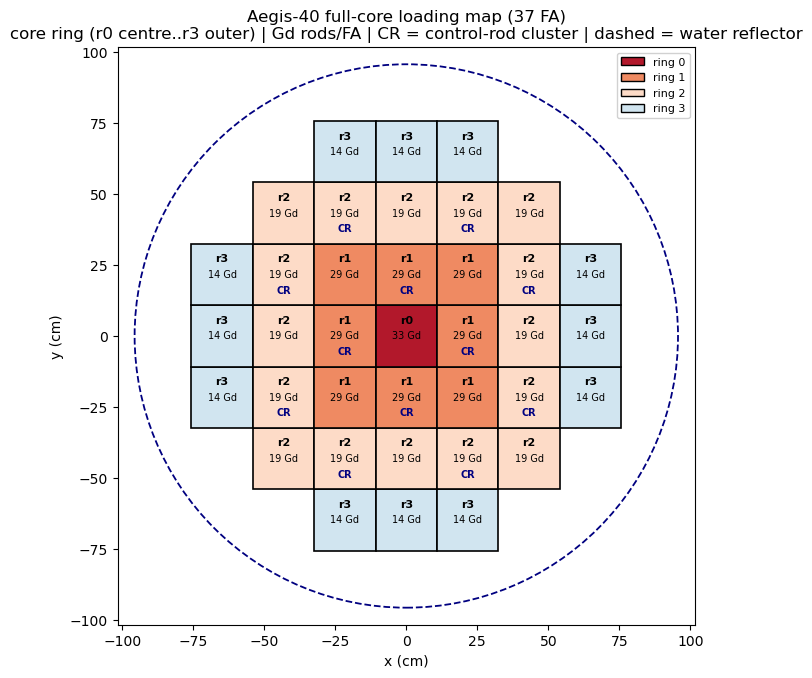

In [10]:
# Full-core loading map (FER figure): core ring zone + Gd rods/FA + control-rod positions
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Patch
fig, ax = plt.subplots(figsize=(7.5, 7.5))
half = (N_CORE - 1) / 2.0
ring_col = {0: "#b2182b", 1: "#ef8a62", 2: "#fddbc7", 3: "#d1e5f0"}
for j in range(N_CORE):
    for i in range(N_CORE):
        if CORE_MAP[N_CORE - 1 - j, i] != 1:
            continue
        r = _core_ring_of(i, j)
        x = (i - half) * FA_PITCH - FA_PITCH / 2
        y = (j - half) * FA_PITCH - FA_PITCH / 2
        ax.add_patch(Rectangle((x, y), FA_PITCH, FA_PITCH,
                               facecolor=ring_col.get(r, "#dddddd"), edgecolor="k", lw=1.2))
        ngd = int(round(N_GD_RODS * (GD_RING_WEIGHTS.get(r, 1.0) if RADIAL_GD_ZONING else 1.0)))
        cx = (i - half) * FA_PITCH
        cy = (j - half) * FA_PITCH
        ax.text(cx, cy + 4.5, f"r{r}", ha="center", fontsize=8, weight="bold")
        ax.text(cx, cy - 1.0, f"{ngd} Gd", ha="center", fontsize=7)
        if CR_MAP[N_CORE - 1 - j, i] == 1:
            ax.text(cx, cy - 6.5, "CR", ha="center", fontsize=7, color="navy", weight="bold")
refl = N_CORE * FA_PITCH / 2
ax.add_patch(plt.Circle((0, 0), refl + RADIAL_REFLECTOR_CM, fill=False, ls="--", color="navy", lw=1.3))
lim = refl + RADIAL_REFLECTOR_CM + 6
ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim); ax.set_aspect("equal")
ax.set_xlabel("x (cm)"); ax.set_ylabel("y (cm)")
ax.set_title(f"Aegis-40 full-core loading map ({N_FA_TOTAL} FA)\n"
             "core ring (r0 centre..r3 outer) | Gd rods/FA | CR = control-rod cluster | dashed = water reflector")
ax.legend(handles=[Patch(facecolor=ring_col[k], edgecolor="k", label=f"ring {k}") for k in (0, 1, 2, 3)],
          loc="upper right", fontsize=8, framealpha=0.9)
try:
    fig.savefig(PLOTS / "core_loading_map.png", dpi=200, bbox_inches="tight")
except Exception:
    fig.savefig("core_loading_map.png", dpi=200, bbox_inches="tight")
plt.show()

saved: /mnt/d/conda-envs/openmc-py311/SMRs/Shielding/aegis40_neutronics_outputs/plots/core_map.png


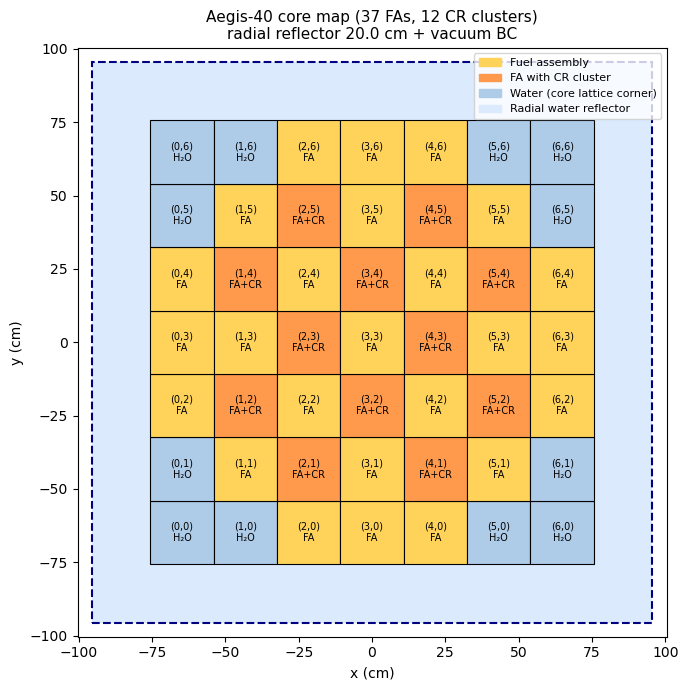

In [12]:
def plot_core_map():
    """Annotated core map (matplotlib)."""
    fig, ax = plt.subplots(figsize=(7, 7))
    cx = (N_CORE - 1) / 2.0
    for j in range(N_CORE):
        for i in range(N_CORE):
            is_fuel = bool(CORE_MAP[N_CORE - 1 - j, i])
            is_cr   = bool(CR_MAP  [N_CORE - 1 - j, i])
            if not is_fuel:
                c = "#aecbe8"; label = "H₂O"
            elif is_cr:
                c = "#ff9a4d"; label = "FA+CR"
            else:
                c = "#ffd35a"; label = "FA"
            x = (i - cx) * FA_PITCH; y = (j - cx) * FA_PITCH
            ax.add_patch(plt.Rectangle((x - FA_PITCH/2, y - FA_PITCH/2),
                         FA_PITCH, FA_PITCH, facecolor=c,
                         edgecolor="black", linewidth=0.8))
            ax.text(x, y, f"({i},{j})\n{label}",
                    ha="center", va="center", fontsize=7)

    # Radial reflector outline
    core_half = N_CORE * FA_PITCH / 2.0
    outer_half = core_half + RADIAL_REFLECTOR_CM
    ax.add_patch(plt.Rectangle((-outer_half, -outer_half),
                 2*outer_half, 2*outer_half,
                 facecolor="#dbeafd", edgecolor="navy",
                 linewidth=1.5, ls="--", zorder=-1, label="Water reflector"))
    ax.set_xlim(-outer_half * 1.05, outer_half * 1.05)
    ax.set_ylim(-outer_half * 1.05, outer_half * 1.05)
    ax.set_aspect("equal")
    ax.set_title(f"Aegis-40 core map ({N_FA_TOTAL} FAs, {N_CR_CLUSTERS} CR clusters)\n"
                 f"radial reflector {RADIAL_REFLECTOR_CM} cm + vacuum BC", fontsize=11)
    patches = [
        mpatches.Patch(color="#ffd35a", label="Fuel assembly"),
        mpatches.Patch(color="#ff9a4d", label="FA with CR cluster"),
        mpatches.Patch(color="#aecbe8", label="Water (core lattice corner)"),
        mpatches.Patch(color="#dbeafd", label="Radial water reflector"),
    ]
    ax.legend(handles=patches, loc="upper right", fontsize=8)
    ax.set_xlabel("x (cm)"); ax.set_ylabel("y (cm)")
    fig.tight_layout()
    out = PLOTS / "core_map.png"
    fig.savefig(out, dpi=200, bbox_inches="tight")
    print(f"saved: {out}")
    plt.show()

plot_core_map()


saved: /mnt/d/conda-envs/openmc-py311/SMRs/Shielding/aegis40_neutronics_outputs/plots/geometry_render_xy.png


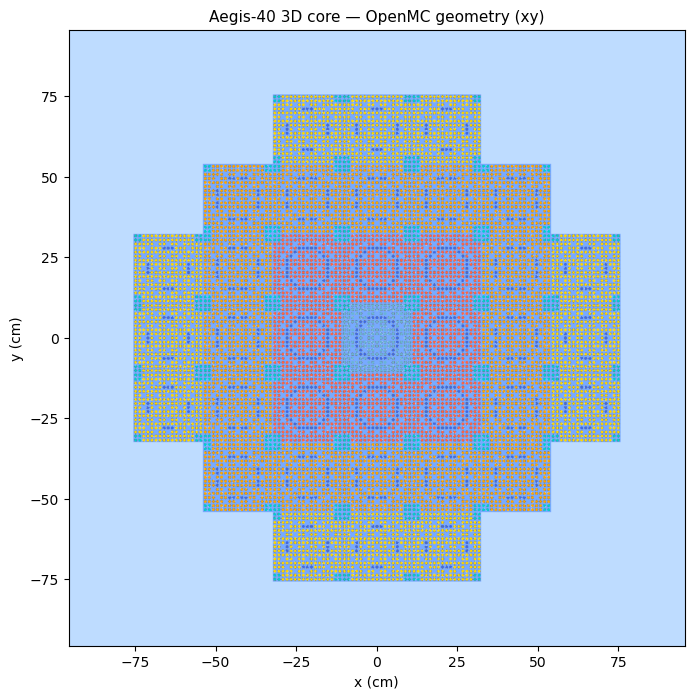

saved: /mnt/d/conda-envs/openmc-py311/SMRs/Shielding/aegis40_neutronics_outputs/plots/geometry_render_xz.png


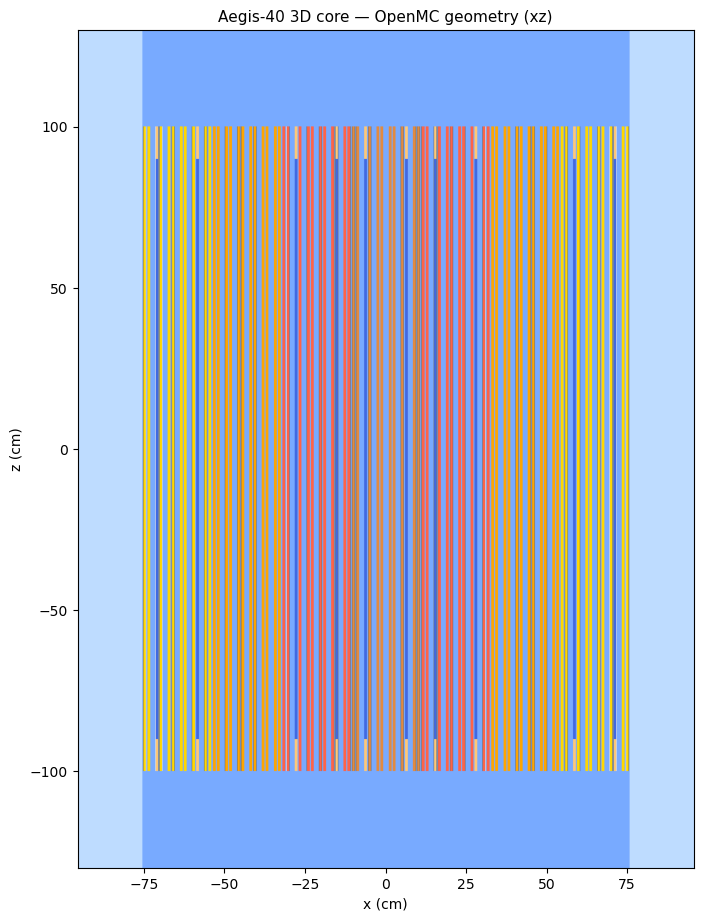

In [13]:
def plot_core_geometry():
    """OpenMC color renders of the 3D core (xy at z=0 and xz at y=0)."""
    model, mat_dict, info = build_core()
    d = _run_dir("00_geometry_plot")
    outer_half = info["outer_half_cm"]
    Z_OUTER    = info["z_outer_cm"]

    palette = {
        "H2O_active":     (120, 170, 255),
        "H2O_reflector":  (190, 220, 255),
        "Zircaloy-4":     (110, 110, 110),
        "He gap":         (230, 230, 230),
        "B4C":            (30, 30, 30),
        "Gd_fuel":        (65, 105, 225),
        "Er_fuel":        (0, 206, 209),
        "Gd_cutback_UO2": (255, 200, 120),
        "UO2_4.0":        (255, 215, 0),
        "UO2_4.4":        (255, 165, 0),
        "UO2_4.7":        (255, 99, 71),
        "UO2_4.95":       (220, 50, 40),
        "core_barrel":      (120, 120, 120),
        "downcomer_water":  (150, 190, 255),
        "SA508_RPV":        (60, 60, 60),
        "cavity_air":       (245, 245, 245),
        "thermal_shield":   (175, 175, 175),
        "borated_PE":       (110, 190, 115),
        "magnetite_concrete": (185, 150, 90),
        "ordinary_concrete":  (210, 190, 160),
    }
    color_map = {m: palette[m.name] for m in model.materials if m.name in palette}

    # xy slice at z=0
    p_xy = openmc.Plot()
    p_xy.filename = "geometry_xy"
    p_xy.basis = "xy"
    p_xy.origin = (0.0, 0.0, 0.0)
    p_xy.width = (2*outer_half, 2*outer_half)
    p_xy.pixels = (1100, 1100)
    p_xy.color_by = "material"
    if color_map: p_xy.colors = color_map

    # xz slice at y=0 — shows active fuel + axial plena
    p_xz = openmc.Plot()
    p_xz.filename = "geometry_xz"
    p_xz.basis = "xz"
    p_xz.origin = (0.0, 0.0, 0.0)
    p_xz.width = (2*outer_half, 2*Z_OUTER)
    p_xz.pixels = (1100, int(1100 * Z_OUTER / outer_half))
    p_xz.color_by = "material"
    if color_map: p_xz.colors = color_map

    model.plots = openmc.Plots([p_xy, p_xz])
    model.export_to_xml(str(d))
    old = Path.cwd(); os.chdir(d)
    try:
        openmc.plot_geometry(output=False)
    finally:
        os.chdir(old)

    for tag, w, h in (("xy", outer_half, outer_half),
                      ("xz", outer_half, Z_OUTER)):
        img = None
        for ext in ("png", "ppm"):
            cand = d / f"geometry_{tag}.{ext}"
            if cand.is_file(): img = cand; break
        if img is None:
            print(f"   render for {tag} produced no image."); continue
        arr = plt.imread(str(img))
        fig, ax = plt.subplots(figsize=(8, 8 * h / w))
        ax.imshow(arr, extent=[-w, w, -h, h])
        ax.set_xlabel("x (cm)"); ax.set_ylabel("y (cm)" if tag == "xy" else "z (cm)")
        ax.set_title(f"Aegis-40 3D core — OpenMC geometry ({tag})", fontsize=11)
        out = PLOTS / f"geometry_render_{tag}.png"
        fig.savefig(out, dpi=200, bbox_inches="tight")
        print(f"saved: {out}")
        plt.show()

plot_core_geometry()


## 7 · Static neutronic parameters and reactivity feedback
Each cell runs a short k-eigenvalue calculation on the 3-D core (real leakage) and stores the result in
`results`: BOC criticality, moderator-temperature, Doppler and void coefficients, control-rod worth and
shutdown margin (most-reactive rod stuck out), maximum enrichment, and the bounding reactivity-insertion
rate. These feed the reactivity-balance and feedback tables (Section 10) and the compliance check
(Section 11).

In [ ]:
# 4.1 — BOC k-effective  (k_eff_bol)  — now with full 3D leakage
def calc_keff_bol():
    print("[1/9] BOC k-effective (3D core, ARO) ...")
    d = _run_dir("01_keff_bol")
    model, _, info = build_core()
    _run_model(model, d, tag="keff_bol")
    k, s = _keff(d)
    results["k_eff_bol"] = k
    results["k_eff_bol_sigma"] = s
    results["core_geometry"] = {
        "n_fuel_assemblies": info["n_fa"],
        "n_cr_clusters": N_CR_CLUSTERS,
        "core_half_width_cm": info["core_half_cm"],
        "outer_half_width_cm": info["outer_half_cm"],
        "z_outer_cm": info["z_outer_cm"],
        "active_height_cm": ACTIVE_HEIGHT,
        "radial_reflector_cm": RADIAL_REFLECTOR_CM,
        "axial_reflector_cm": AXIAL_REFLECTOR_CM,
    }
    print(f"   k_eff_BOL = {k:.5f} ± {s*1e5:.0f} pcm  (with leakage)")
    return k, s

calc_keff_bol()


[1/9] BOC k-effective (3D core, ARO) ...


In [ ]:
# 4.2 — Moderator Temperature Coefficient  [hard: < 0]
def calc_mtc(dT=25.0):
    print("[2/9] MTC (3D) ...")
    rows = {}
    for tag, Tm in [("cold", T_MOD_K - dT), ("hot", T_MOD_K + dT)]:
        d = _run_dir("02_mtc", tag)
        rho_w = float(np.clip(RHO_WATER_NOM - 0.00115 * (Tm - T_MOD_K), 0.45, 0.95))
        model, _, _ = build_core(mod_temp=Tm, water_density=rho_w)
        _run_model(model, d, tag=f"mtc_{tag}")
        k, _ = _keff(d); rows[tag] = k
        print(f"   T_mod={Tm:.0f} K -> k={k:.5f}")
    mtc = _pcm(rows["cold"], rows["hot"]) / (2 * dT)
    results["mtc_full_power_pcm_per_K"] = mtc
    print(f"   MTC = {mtc:+.2f} pcm/K  ({'PASS' if mtc < 0 else 'FAIL'} hard <0)")
    return mtc

calc_mtc()


In [ ]:
# 4.3 — Doppler (fuel temperature) coefficient  [hard: < 0]
def calc_dtc(dT=150.0):
    print("[3/9] DTC (3D) ...")
    rows = {}
    for tag, Tf in [("cold", T_FUEL_K - dT), ("hot", T_FUEL_K + dT)]:
        d = _run_dir("03_dtc", tag)
        model, _, _ = build_core(fuel_temp=Tf)
        _run_model(model, d, tag=f"dtc_{tag}")
        k, _ = _keff(d); rows[tag] = k
        print(f"   T_fuel={Tf:.0f} K -> k={k:.5f}")
    dtc = _pcm(rows["cold"], rows["hot"]) / (2 * dT)
    results["dtc_pcm_per_K"] = dtc
    print(f"   DTC = {dtc:+.2f} pcm/K  ({'PASS' if dtc < 0 else 'FAIL'} hard <0)")
    return dtc

calc_dtc()


In [ ]:
# 4.4 — Void coefficient  [hard: < 0]
def calc_void_coeff(void_hi_pct=10.0):
    print("[4/9] Void coefficient (3D) ...")
    k0, _ = _keff(_run_dir("01_keff_bol"))          # reuse BOC (0% void)
    d = _run_dir("04_void", f"void{void_hi_pct:.0f}pct")
    model, _, _ = build_core(void_fraction=void_hi_pct/100.0)
    _run_model(model, d, tag=f"void_{void_hi_pct:.0f}pct")
    kv, _ = _keff(d)
    vc = _pcm(k0, kv) / void_hi_pct
    results["void_coeff_pcm_per_pct"] = vc
    print(f"   k(0%)={k0:.5f}  k({void_hi_pct:.0f}%)={kv:.5f}")
    print(f"   Void coeff = {vc:+.2f} pcm/%void  ({'PASS' if vc < 0 else 'FAIL'} hard <0)")
    return vc

calc_void_coeff()


In [ ]:
# 4.5 — Control rod worth (full bank ARO vs ARI) + shutdown margin (3D core)
#
# In the 3D core the SDM is meaningful: insert ALL CR clusters except the highest-worth one
# ("worst stuck rod"). The geometric centre (N_CORE//2, N_CORE//2) is the instrument
# assembly (no CRA), so we approximate the highest-worth cluster as the innermost ACTUAL
# cluster (nearest the centre = largest neutronic importance in a small symmetric core).
def calc_rod_worth_and_sdm():
    print("[5/9] Rod worth + SDM (3D, full-core) ...")
    k_aro, _ = _keff(_run_dir("01_keff_bol"))

    # All-rods-in
    d_ari = _run_dir("05_rod_worth", "ari")
    model_ari, _, _ = build_core(control_rod_state="ari")
    _run_model(model_ari, d_ari, tag="rod_ari")
    k_ari, _ = _keff(d_ari)
    total_worth_pcm = abs(_pcm(k_aro, k_ari))
    print(f"   k_ARO={k_aro:.5f}  k_ARI={k_ari:.5f}  total bank worth={total_worth_pcm:.0f} pcm")

    # Worst stuck rod: insert all clusters except the most-reactive (innermost) one.
    all_cr = {(i, j) for j in range(N_CORE) for i in range(N_CORE)
              if CR_MAP[N_CORE - 1 - j, i] == 1}
    centre = (N_CORE // 2, N_CORE // 2)
    central = min(all_cr, key=lambda p: (p[0]-centre[0])**2 + (p[1]-centre[1])**2)
    stuck_set = all_cr - {central}
    d_stuck = _run_dir("05_rod_worth", "ari_minus_central")
    model_st, _, _ = build_core(control_rod_state=stuck_set)
    _run_model(model_st, d_stuck, tag="rod_stuck")
    k_stuck, _ = _keff(d_stuck)
    central_worth_pcm = abs(_pcm(k_stuck, k_ari))    # Δρ added by *inserting* the central rod
    sdm_pct = abs(_rho(k_stuck)) * 100.0             # |ρ| when central rod is stuck out

    results["control_rod_worth_aro_pcm"]       = total_worth_pcm
    results["control_rod_worth_aro_dk"]        = abs(k_aro - k_ari)
    results["central_rod_worth_pcm"]           = central_worth_pcm
    results["k_eff_ari"]                       = k_ari
    results["k_eff_stuck_rod"]                 = k_stuck
    results["shutdown_margin_dk_pct"]          = sdm_pct
    print(f"   central CR cluster worth ~ {central_worth_pcm:.0f} pcm")
    print(f"   SDM (ARI minus central, k_stuck={k_stuck:.5f}) "
          f"= {sdm_pct:.3f} % dk/k  ({'PASS' if sdm_pct >= 1.0 else 'FAIL'} hard ≥1%)")
    print(f"   Total CR bank worth = {total_worth_pcm:.0f} pcm  "
          f"({'PASS' if total_worth_pcm >= 5000 else 'FAIL'} op ≥5000)")
    return total_worth_pcm, sdm_pct

calc_rod_worth_and_sdm()


In [ ]:
# 4.6 — Enrichment (design input)  [hard: ≤5%]
def record_enrichment():
    results["enrichment_max_pct"] = max(ENRICH_INNER, ENRICH_MID, ENRICH_OUTER)
    # Count-weighted core average over the 264 fuel pins, honouring the
    # FA-perimeter edge grading and Gd/Er pins (ENRICH_MID base U).
    _gd = set(GD_POSITIONS); _er = set(ER_POSITIONS)
    _e = [ENRICH_MID if (i, j) in _gd or (i, j) in _er
          else _enrichment_for_pin(i, j) for (i, j) in FUEL_POS]
    results["enrichment_avg_pct"] = round(float(np.mean(_e)), 3)
    print(f"[6/9] Max enrichment = {results['enrichment_max_pct']} wt%  "
          f"({'PASS' if results['enrichment_max_pct'] <= 5.0 else 'FAIL'} hard ≤5%)  "
          f"| count-weighted avg ~ {results['enrichment_avg_pct']:.2f} wt% over {len(FUEL_POS)} pins")

record_enrichment()


In [ ]:
# 4.7 — Max reactivity insertion rate (CRDM design)  [hard: ≤7.5e-4 dk/k/s]
def record_max_rir(crdm_steps_per_min=45.0, diff_worth_pcm_per_step=2.0):
    rate_pcm_s = crdm_steps_per_min / 60.0 * diff_worth_pcm_per_step
    rate_dk_s  = rate_pcm_s / 1e5
    results["max_reactivity_rate"]           = rate_dk_s
    results["max_reactivity_rate_pcm_per_s"] = rate_pcm_s
    print(f"[7/9] CRDM rate = {rate_pcm_s:.2f} pcm/s = {rate_dk_s:.2e} dk/k/s  "
          f"({'PASS' if rate_dk_s <= 7.5e-4 else 'FAIL'} hard ≤7.5e-4)  "
          f"| margin {7.5e-4/rate_dk_s:.0f}×")

record_max_rir()


## 8 · Depletion: initial (BOC) to equilibrium cycle
Full 3-D depletion at design specific power. With leakage included, k drops below 1 during the cycle, so
the cycle length is the EFPD at which k = 1 (not a placeholder). The multi-batch equilibrium discharge
burn-up follows from the linear-reactivity model (BU_discharge ~ N_BATCHES x BU_cycle). The k-eff vs
burn-up curve (BOC -> EOC), the Gd/Er inventory evolution, and the per-assembly burn-up distribution at
EOC are produced here. Total power 125 MWth over 37 FA ~ 3.38 MWth/FA; specific power
125/9.87 = 12.7 W/gHM.

In [ ]:
def extract_absorber_inventory(dep_results, run_dir):
    """Gd-157 / Er-167 atom-density evolution.

    FIX (Finding 6): the absorber inventory is now reported AT THE CYCLE EOC
    burnup (fresh-core B1, where k=1), not at the end of the full ~1900-EFPD
    depletion horizon.  Reading the last horizon step made Er-167 look ~3 %
    "remaining" because that point is ~170 GWd/t — far past the ~43 GWd/t the
    fuel actually sees.  Er is a slow burner, so a substantial residual at the
    real EOC is expected and supports cold shutdown margin."""
    run_dir = Path(run_dir)
    name_by_id = {}
    mats_xml = run_dir / "materials.xml"
    if mats_xml.is_file():
        try:
            for m in openmc.Materials.from_xml(str(mats_xml)):
                name_by_id[str(m.id)] = m.name
        except Exception as e:
            print(f"   could not parse materials.xml: {e}")
    gd_ids = [i for i, n in name_by_id.items() if "Gd" in n]
    er_ids = [i for i, n in name_by_id.items() if "Er" in n]

    def _sum_atoms(ids, nuc):
        tot = times = None
        for mid in ids:
            try:
                t, a = dep_results.get_atoms(mid, nuc)
            except Exception:
                continue
            a = np.array(a, float); times = np.array(t, float)
            tot = a if tot is None else tot + a
        return times, tot

    t_gd, gd157 = _sum_atoms(gd_ids, "Gd157")
    t_er, er167 = _sum_atoms(er_ids, "Er167")
    base_t = t_gd if t_gd is not None else t_er
    burnup = SPECIFIC_POWER * base_t / 86400.0 / 1000.0 if base_t is not None else None

    # cycle-relevant EOC burnup: fresh-core B1 (k=1 crossing) if known, else
    # the equilibrium discharge target.
    b1_efpd = results.get("fresh_core_B1_efpd")
    if b1_efpd:
        eoc_bu = SPECIFIC_POWER * float(b1_efpd) / 1000.0
    else:
        eoc_bu = results.get("burnup_discharge_GWd_per_MTU")

    def _at_eoc(frac):
        if burnup is None or eoc_bu is None:
            return None
        return float(np.interp(eoc_bu, burnup, frac) * 100.0)

    fig, ax = plt.subplots(figsize=(8, 5)); plotted = False
    if gd157 is not None and gd157[0] > 0:
        gdf = gd157 / gd157[0]
        ax.plot(burnup, gdf*100, "o-", color="navy", label="Gd-157 / Gd-157₀")
        results["gd157_eoc_fraction_pct"]      = round(_at_eoc(gdf), 1) if _at_eoc(gdf) is not None else None
        results["gd157_endhorizon_pct"]        = round(float(gdf[-1]*100), 1)
        plotted = True
    if er167 is not None and er167[0] > 0:
        erf = er167 / er167[0]
        ax.plot(burnup, erf*100, "s--", color="darkorange", label="Er-167 / Er-167₀")
        results["er167_eoc_fraction_pct"]      = round(_at_eoc(erf), 1) if _at_eoc(erf) is not None else None
        results["er167_endhorizon_pct"]        = round(float(erf[-1]*100), 1)
        plotted = True
    if plotted:
        if eoc_bu is not None:
            ax.axvline(eoc_bu, color="green", ls=":", lw=1.5,
                       label=f"cycle EOC ≈ {eoc_bu:.0f} GWd/t")
        ax.set_xlabel("Core-average burnup (GWd/tHM)")
        ax.set_ylabel("Remaining absorber inventory (%)")
        ax.set_title("Absorber Inventory Depletion — Aegis-40 (3D core)")
        ax.set_ylim(0, 110); ax.legend(); ax.grid(alpha=0.3)
        out = PLOTS / "absorber_inventory.png"
        fig.savefig(out, dpi=200, bbox_inches="tight"); print(f"   saved: {out}")
        plt.show()
        print(f"   Gd-157 @ EOC(~{eoc_bu:.0f} GWd/t) = {results.get('gd157_eoc_fraction_pct')}%"
              f"  (design: nearly depleted by EOC — fast burnout, holds BOC spike)")
        print(f"   Er-167 @ EOC(~{eoc_bu:.0f} GWd/t) = {results.get('er167_eoc_fraction_pct')}%"
              f"  (design: slow burner; notable residual expected — aids cold SDM)")
        print(f"   [diagnostic] end-of-horizon: Gd-157 {results.get('gd157_endhorizon_pct')}%, "
              f"Er-167 {results.get('er167_endhorizon_pct')}%")
    else:
        plt.close(fig); print("   no absorber atom data extracted.")


In [ ]:
# ============================================================================
# 3D-core depletion → fresh-core B1, then 4-batch EQUILIBRIUM via the
# linear-reactivity model (LRM). run_core_depletion() is reused by the
# Equilibrium-cycle depletion.
#
# LRM (n batches):   B_discharge = 2n/(n+1) · B1 ,   cycle = 2/(n+1) · B1
#   where B1 = burnup at which a FRESH, uniformly-loaded core reaches k = 1.
#   (The old notebook used B_discharge = n · B1, over-counting by ~2.5×.)
# ============================================================================

def _assign_depletion_volumes(model, verbose=True):
    """Set .volume on every depletable material, summing pin counts across the
       radial rings so per-ring Gd zoning is accounted for.  Plain fuel is keyed
       by material NAME so changed enrichments can't fall through."""
    pin_vol_full = math.pi * FUEL_RADIUS**2 * ACTIVE_HEIGHT
    gd_mid_h     = ACTIVE_HEIGHT - 2.0 * GD_AXIAL_CUT_CM

    # how many fuelled FAs sit in each radial ring (0=centre ... outer ring)
    ring_fa = {}
    for j in range(N_CORE):
        for i in range(N_CORE):
            if CORE_MAP[N_CORE - 1 - j, i] == 1:
                r = _core_ring_of(i, j)
                ring_fa[r] = ring_fa.get(r, 0) + 1

    counts_name = {}                       # plain-fuel material -> core-total pins
    gd_pins_total = er_pins_total = 0
    tot_inner = tot_mid = tot_outer = 0
    for ring, nfa in ring_fa.items():
        if nfa == 0:
            continue
        if RADIAL_GD_ZONING:
            gd = _gd_positions_for_ring(ring); er = _er_positions_for_ring(ring)
        else:
            gd, er = GD_POSITIONS, ER_POSITIONS
        plain = [p for p in FUEL_POS if p not in gd and p not in er]
        n_inner = sum(1 for p in plain if _pin_radius(*p) < ZONE_R1_CM)
        n_mid   = sum(1 for p in plain if ZONE_R1_CM <= _pin_radius(*p) < ZONE_R2_CM)
        n_outer = sum(1 for p in plain if _pin_radius(*p) >= ZONE_R2_CM)
        for nm, c in ((f"UO2_{ENRICH_INNER:.1f}", n_inner),
                      (f"UO2_{ENRICH_MID:.1f}",   n_mid),
                      (f"UO2_{ENRICH_OUTER:.1f}", n_outer)):
            counts_name[nm] = counts_name.get(nm, 0) + c * nfa
        gd_pins_total += len(gd) * nfa
        er_pins_total += len(er) * nfa
        tot_inner += n_inner * nfa; tot_mid += n_mid * nfa; tot_outer += n_outer * nfa

    vol_map = {nm: pin_vol_full * c for nm, c in counts_name.items()}
    vol_map["Gd_fuel"]        = math.pi*FUEL_RADIUS**2 * gd_mid_h          * gd_pins_total
    vol_map["Gd_cutback_UO2"] = math.pi*FUEL_RADIUS**2 * 2*GD_AXIAL_CUT_CM * gd_pins_total
    vol_map["Er_fuel"]        = pin_vol_full * er_pins_total

    u_frac = 238.03 / (238.03 + 2*15.999)
    u_mass_g = 0.0
    for m in model.materials:
        if not getattr(m, "depletable", False):
            continue
        v = vol_map.get(m.name)
        if not v or v <= 0:
            v = pin_vol_full
            if verbose: print(f"   WARNING: volume fallback for '{m.name}'")
        m.volume = v
        u_mass_g += v * RHO_UO2 * u_frac
    return u_mass_g, dict(n_inner=tot_inner, n_mid=tot_mid, n_outer=tot_outer,
                          gd_pins=gd_pins_total, er_pins=er_pins_total)


def run_core_depletion(timesteps_d, stats, tag="depletion",
                       make_plots=False, verbose=True):
    """Deplete the fresh core; return (metrics_dict, Results, run_dir).
       metrics carry fresh-core B1 + the LRM equilibrium cycle / discharge BU."""
    d = _run_dir(f"08_depletion_{tag}")
    for pat in ("*.h5", "*.xml"):
        for f in d.glob(pat):
            f.unlink(missing_ok=True)

    model, mat_dict, info = build_core(stats=stats)
    u_mass_g, zinfo = _assign_depletion_volumes(model, verbose=verbose)
    if verbose:
        print(f"   U ~ {u_mass_g/1000:.1f} kgU | plain pins(core) "
              f"inner{zinfo['n_inner']} mid{zinfo['n_mid']} outer{zinfo['n_outer']} "
              f"| Gd {zinfo['gd_pins']} Er {zinfo['er_pins']} (core totals)")

    # Per-assembly fission mesh — tallied at EVERY depletion step so the BOC/MOC/EOC
    # power maps and the EOC per-assembly burn-up map can be reconstructed downstream.
    _ch = info["core_half_cm"]
    _fa_mesh = openmc.RegularMesh(); _fa_mesh.dimension = (N_CORE, N_CORE, 20)
    _fa_mesh.lower_left  = (-_ch, -_ch, -ACTIVE_HEIGHT / 2.0)
    _fa_mesh.upper_right = ( _ch,  _ch,  ACTIVE_HEIGHT / 2.0)
    _fa_t = openmc.Tally(name="fa_fission")
    _fa_t.filters = [openmc.MeshFilter(_fa_mesh)]; _fa_t.scores = ["fission"]
    model.tallies = openmc.Tallies([_fa_t])

    power_W = CORE_POWER_MWT * 1e6
    model.export_to_xml(str(d))
    operator = openmc.deplete.CoupledOperator(model, chain_file=str(CHAIN))
    integrator = openmc.deplete.PredictorIntegrator(
        operator, timesteps_d, power=power_W, timestep_units="d")
    old = Path.cwd(); os.chdir(d)
    t0 = time.time()
    try:
        integrator.integrate()
    finally:
        os.chdir(old)
    dt = time.time() - t0
    runtime_log.append((f"deplete_{tag}", dt))

    h5 = d / "depletion_results.h5"
    if not h5.is_file():
        raise FileNotFoundError(f"depletion_results.h5 missing in {d}")
    dep = openmc.deplete.Results(str(h5))
    try:
        t_s, karr = dep.get_keff(time_units="d"); time_d = np.array(t_s, float)
    except TypeError:
        t_s, karr = dep.get_keff(); time_d = np.array(t_s, float) / 86400.0
    karr = np.array(karr, float)
    kv   = karr[:, 0] if karr.ndim == 2 else karr
    ksig = karr[:, 1] if karr.ndim == 2 else np.zeros_like(kv)
    burnup = SPECIFIC_POWER * time_d / 1000.0          # GWd/tHM
    n = N_BATCHES

    # fresh-core B1: first crossing of k = 1 (else extrapolate the decline)
    crossed = extrapolated = False
    B1_efpd = None
    ge = kv >= 1.0
    # LAST downward crossing of k=1: ignores the early xenon dip and any
    # Gd-burnout hump -> B1 is the true end-of-life crossing (else extrapolate).
    downs = [i for i in range(len(kv) - 1) if ge[i] and not ge[i + 1]]
    if downs:
        i = downs[-1]
        t1, t2, k1, k2 = time_d[i], time_d[i + 1], kv[i], kv[i + 1]
        B1_efpd = float(t1 + (1.0 - k1) / (k2 - k1) * (t2 - t1)); crossed = True
    elif not ge[0]:
        B1_efpd = 0.0; crossed = True
    elif len(kv) >= 2 and (kv[-1] - kv[-2]) < 0:
        slope = (kv[-1] - kv[-2]) / (time_d[-1] - time_d[-2])
        B1_efpd = float(time_d[-1] + (1.0 - kv[-1]) / slope); extrapolated = True

    m = dict(
        tag=tag, run_dir=str(d), runtime_s=round(dt, 1),
        time_d=time_d.tolist(), burnup=burnup.tolist(),
        k=kv.tolist(), k_sigma=ksig.tolist(),
        k_bol=float(kv[0]), k_eoc=float(kv[-1]),
        k_max=float(kv.max()), k_min=float(kv.min()),
        bol_excess_pcm=float(_rho(kv[0]) * 1e5),
        peak_excess_pcm=float(_rho(kv.max()) * 1e5),
        swing_pcm=float((_rho(kv.max()) - _rho(kv.min())) * 1e5),
        crossed=crossed, extrapolated=extrapolated,
        horizon_efpd=float(time_d[-1]),
        fresh_B1_efpd=None, fresh_B1_burnup_GWd_t=None,
        equilibrium_cycle_efpd=None, equilibrium_cycle_months=None,
        discharge_burnup_GWd_t=None,
    )
    if B1_efpd and B1_efpd > 0:
        B1_bu = SPECIFIC_POWER * B1_efpd / 1000.0
        m["fresh_B1_efpd"]            = B1_efpd
        m["fresh_B1_burnup_GWd_t"]    = B1_bu
        m["equilibrium_cycle_efpd"]   = 2.0 / (n + 1) * B1_efpd
        m["equilibrium_cycle_months"] = 2.0 / (n + 1) * B1_efpd / 30.44
        m["discharge_burnup_GWd_t"]   = 2.0 * n / (n + 1) * B1_bu

    if make_plots:
        fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
        axes[0].errorbar(burnup, kv, yerr=ksig, fmt="o-", color="#1a6faf", capsize=4, lw=2)
        axes[0].axhline(1.0, color="red", ls="--", lw=1.5, label="k=1")
        axes[0].set_xlabel("Fresh-core burnup (GWd/tHM)"); axes[0].set_ylabel("k-effective")
        axes[0].set_title("Aegis-40 fresh-core depletion (leaky 3D)")
        axes[0].legend(); axes[0].grid(alpha=0.3)
        axes[1].plot(burnup, _rho(kv) * 1e5, "s-", color="#c0392b", lw=2)
        axes[1].axhline(0, color="black", ls="--", lw=1)
        axes[1].set_xlabel("Fresh-core burnup (GWd/tHM)"); axes[1].set_ylabel("Excess reactivity ρ (pcm)")
        axes[1].set_title("Reactivity vs burnup (flat = good)"); axes[1].grid(alpha=0.3)
        fig.tight_layout()
        out = PLOTS / f"depletion_{tag}.png"
        fig.savefig(out, dpi=200, bbox_inches="tight"); print(f"   saved: {out}")
        plt.show()
    return m, dep, d


def calc_depletion():
    print("[8/9] 3D-core depletion → fresh B1 → 4-batch equilibrium (LRM) ...")
    timesteps = [10, 20, 30, 40] + [45] * 16 + [150] * 19     # ~3670 EFPD (~46 GWd/tHM): fine (~0.5 GWd/t) through Gd burnout, then coarse. 37-FA specific power 12.7 MW/tHM (half the old 21-FA) -> horizon must reach ~46 GWd/t for fresh-core k to cross 1 (a 1945-EFPD run stopped at 24.6 GWd/t, k_EOC=1.009).
    m, dep, d = run_core_depletion(timesteps, STAT_MEDIUM, tag="baseline",
                                   make_plots=True, verbose=True)
    results["k_eff_bol_depletion"]          = m["k_bol"]
    results["k_eff_eoc_depletion"]          = m["k_eoc"]
    results["depletion_bol_excess_pcm"]     = round(m["bol_excess_pcm"], 0)
    results["depletion_peak_excess_pcm"]    = round(m["peak_excess_pcm"], 0)
    results["depletion_swing_pcm"]          = round(m["swing_pcm"], 0)
    results["fresh_core_B1_efpd"]           = m["fresh_B1_efpd"]
    results["cycle_length_efpd"]            = m["equilibrium_cycle_efpd"]
    results["burnup_discharge_GWd_per_MTU"] = m["discharge_burnup_GWd_t"]
    results["depletion_burnup_GWd_t"]       = m["burnup"]
    results["depletion_time_d"]             = m["time_d"]
    results["depletion_run_dir"]            = m["run_dir"]

    if m["crossed"] or m["extrapolated"]:
        note = " (extrapolated past horizon)" if m["extrapolated"] else ""
        print(f"   fresh-core B1 = {m['fresh_B1_efpd']:.0f} EFPD "
              f"= {m['fresh_B1_burnup_GWd_t']:.1f} GWd/tHM{note}")
        print(f"   → 4-batch equilibrium cycle    = {m['equilibrium_cycle_months']:.1f} months "
              f"({m['equilibrium_cycle_efpd']:.0f} EFPD)   [target 12-18 mo]")
        print(f"   → equilibrium discharge burnup = {m['discharge_burnup_GWd_t']:.1f} GWd/tHM "
              f"[target ~50; hard ≤62]")
    else:
        print(f"   WARNING: fresh-core k never reached 1 within {m['horizon_efpd']:.0f} EFPD "
              f"and is not yet declining.")
        print(f"   k_BOL={m['k_bol']:.4f}  k_EOC={m['k_eoc']:.4f}  peak excess "
              f"{m['peak_excess_pcm']:.0f} pcm → too much excess reactivity (add BA) "
              f"or extend the horizon.")
    print(f"   BOC ARO excess = {m['bol_excess_pcm']:.0f} pcm "
          f"(SBF: want small positive, rods trim) | reactivity swing = {m['swing_pcm']:.0f} pcm")
    extract_absorber_inventory(dep, run_dir=d)
    return m

calc_depletion()


## 9 · Power and flux distributions
Power peaking is reconstructed pin-by-pin from a fine 3-D fission mesh: the enthalpy-rise factor F-dH
(radial, axially integrated -> statistically robust), the axial factor F-z, and the 3-D heat-flux factor
F-Q. The reported F-Q is the **separable** F-dH x F-z; the raw single-node 3-D maximum is a Monte-Carlo
artefact at finite statistics (it falls toward the separable value as particles increase) and is kept only
as a diagnostic. Radial and axial power shapes and thermal/fast/total flux maps are produced at
BOC (and at MOC/EOC when the depletion statepoints are supplied).

In [ ]:
## 6 · 3D power peaking — per-pin reconstruction (Findings 1 & 3)
# F_ΔH and F_q are computed pin-by-pin from absolute coordinates, NOT from a
# coarse RegularMesh max/mean.  The old one-cell-per-pin mesh drifted ~0.7 cm
# (>½ pin) across the core because FA_PITCH/17 ≠ PIN_PITCH (0.072 cm water gap
# per side), and its `>0` mask kept water-gap/edge cells that deflated the mean
# and inflated F_ΔH to a non-physical 2.27.  Here every fuel pin's power is
# summed from a fine mesh by footprint, guide tubes / water gaps excluded by
# construction.  Reshape order is made explicit (Finding 2 root cause).

def _fuel_pin_geom():
    """Absolute (x,y) centres of every fuel pin + the FA id it belongs to.
       Excludes the 25 guide/instrument tubes per FA and non-fuel corner FAs.
       The 17×17 Westinghouse guide map is transpose-symmetric, so the SET of
       pin coordinates is independent of the (i,j) axis convention."""
    half    = (N_CORE - 1) / 2.0
    pin_off = (N_PIN  - 1) / 2.0
    px, py, fa = [], [], []
    fid = 0
    fa_ij = {}
    for j in range(N_CORE):
        for i in range(N_CORE):
            if CORE_MAP[N_CORE - 1 - j, i] != 1:
                continue
            fa_ij[fid] = (i, j)
            cx = (i - half) * FA_PITCH
            cy = (j - half) * FA_PITCH
            for (pi, pj) in FUEL_POS:
                px.append(cx + (pi - pin_off) * PIN_PITCH)
                py.append(cy + (pj - pin_off) * PIN_PITCH)
                fa.append(fid)
            fid += 1
    return np.array(px), np.array(py), np.array(fa, int), fid, fa_ij


def _reshape_mesh_xyz(flat, nx, ny, nz):
    """OpenMC mesh elements are ordered x-fastest, then y, then z
       (element id = ix + iy*nx + iz*nx*ny).  Reshape WITHOUT guessing:
       flat -> [iz, iy, ix] in C-order, then transpose to [ix, iy, iz].
       This removes the axial-reshape ambiguity flagged in the review."""
    return np.asarray(flat, float).reshape(nz, ny, nx).transpose(2, 1, 0)


# Engineering uncertainty on the raw MC peak (nuclear + measurement),
# per SSG-52 §3.18(f).  ~3 % is the NuScale-class allowance.
PEAKING_UNC = 1.03
F_DH_LIMIT, F_DH_DESIGN = 1.65, 1.55      # NUREG-1431 3.2.2 / our design target
F_Q_LIMIT,  F_Q_DESIGN  = 2.32, 2.00      # NUREG-1431 3.2.1 (K(z)=1 anchor)


def calc_flux_peaking():
    print("[9/9] Pin-power peaking (per-pin reconstruction) + 3D flux maps ...")
    d = _run_dir("09_flux_peaking")
    model, _, info = build_core()
    outer_half = info["outer_half_cm"]
    H = ACTIVE_HEIGHT
    S = N_CORE * FA_PITCH

    # Fine 3D fission mesh: ~3 cells per pin pitch so each pin footprint is
    # resolved from ABSOLUTE coordinates (immune to FA water-gap drift).
    CELLS_PER_PIN = 3
    NF = int(round(S / (PIN_PITCH / CELLS_PER_PIN)))
    NZ = 40
    mesh_3d = openmc.RegularMesh(); mesh_3d.dimension = (NF, NF, NZ)
    mesh_3d.lower_left  = (-S/2, -S/2, -H/2)
    mesh_3d.upper_right = ( S/2,  S/2,  H/2)
    t3d = openmc.Tally(name="fission_3d")
    t3d.filters = [openmc.MeshFilter(mesh_3d)]; t3d.scores = ["fission"]

    # Fine xy slice at z≈0 — cosmetic radial map only
    mesh_fine = openmc.RegularMesh(); mesh_fine.dimension = (200, 200, 1)
    mesh_fine.lower_left  = (-outer_half, -outer_half, -10)
    mesh_fine.upper_right = ( outer_half,  outer_half,  10)
    t_fine = openmc.Tally(name="fission_fine_xy")
    t_fine.filters = [openmc.MeshFilter(mesh_fine)]; t_fine.scores = ["fission"]

    model.tallies = openmc.Tallies([t3d, t_fine])
    _run_model(model, d, tag="flux_peaking")

    sps = sorted(d.glob("statepoint.*.h5"))
    with openmc.StatePoint(str(sps[-1])) as sp:
        flat3d = sp.get_tally(name="fission_3d").get_values(scores=["fission"]).ravel()
        flatxy = sp.get_tally(name="fission_fine_xy").get_values(scores=["fission"]).ravel()

    f3d = _reshape_mesh_xyz(flat3d, NF, NF, NZ)          # [ix, iy, iz]

    # —— per-pin fission-rate DENSITY by footprint (mean over captured cells:
    #    using mean not sum cancels the ±1-cell quantization in pin volume) ——
    px, py, fa_id, n_fa, fa_ij = _fuel_pin_geom()
    dx = S / NF
    xc = -S/2 + (np.arange(NF) + 0.5) * dx
    h  = PIN_PITCH / 2.0
    npins = len(px)
    pin_z = np.zeros((npins, NZ))
    for p in range(npins):
        ix = np.where((xc >= px[p] - h) & (xc < px[p] + h))[0]
        iy = np.where((xc >= py[p] - h) & (xc < py[p] + h))[0]
        if ix.size and iy.size:
            pin_z[p] = f3d[ix.min():ix.max()+1, iy.min():iy.max()+1, :].mean(axis=(0, 1))
    pin_col = pin_z.sum(axis=1)                          # axial-integrated column
    good = pin_col > 0
    pin_col_g = pin_col[good]; pin_z_g = pin_z[good]

    F_dh = float(pin_col_g.max() / pin_col_g.mean())     # radial enthalpy-rise
    F_q_raw = float(pin_z_g.max() / pin_z_g.mean())      # raw single-node 3-D max (diagnostic)
    fz   = pin_z_g.sum(axis=0); fz_norm = fz / fz.mean()
    F_z  = float(fz_norm.max())
    F_q  = F_dh * F_z                                    # separable F_q = F_dH x F_z (reported)

    F_dh_e = F_dh * PEAKING_UNC                           # design values vs limits
    F_q_e  = F_q  * PEAKING_UNC

    results["pin_peaking_factor_Fq"]      = round(F_q_e, 3)
    results["radial_peaking_FdeltaH"]     = round(F_dh_e, 3)
    results["pin_peaking_factor_Fq_raw"]  = round(F_q_raw, 3)
    results["radial_peaking_FdeltaH_raw"] = round(F_dh, 3)
    results["axial_peaking_Fz"]           = round(F_z, 3)

    def _pf(v, lim): return "PASS" if v <= lim else "FAIL"
    print(f"   F_ΔH (radial, per-pin) = {F_dh:.3f} raw → {F_dh_e:.3f} (+{(PEAKING_UNC-1)*100:.0f}% unc)"
          f"  | limit {F_DH_LIMIT} [{_pf(F_dh_e, F_DH_LIMIT)}]  design {F_DH_DESIGN} [{_pf(F_dh_e, F_DH_DESIGN)}]")
    print(f"   F_q  (separable FdH*Fz)= {F_q:.3f} → {F_q_e:.3f} (+unc)"
          f"  | limit {F_Q_LIMIT} [{_pf(F_q_e, F_Q_LIMIT)}]  design {F_Q_DESIGN} [{_pf(F_q_e, F_Q_DESIGN)}]")
    print(f"   F_z  (axial)           = {F_z:.3f}")
    print(f"   fuel pins counted = {int(good.sum())} (expect {n_fa}×264 = {n_fa*264})")

    # —— DIAGNOSTIC: where do the hottest pins live? (driver identification) ——
    _gt = set(GUIDE_ALL)
    _idx_g = np.where(good)[0]
    def _descr(gp):
        fid = fa_id[gp]; ci, cj = fa_ij[fid]; ring = _core_ring_of(ci, cj)
        pi, pj = FUEL_POS[gp % len(FUEL_POS)]
        gtadj = any((pi+di, pj+dj) in _gt for di, dj in ((1,0),(-1,0),(0,1),(0,-1)))
        edge  = (pi in (0, N_PIN-1) or pj in (0, N_PIN-1))
        # core-facing = pin sits on the half of the FA nearer the core centre
        cc = (N_PIN-1)/2.0; corefacing = ((ci-2)*(pi-cc) + (cj-2)*(pj-cc)) < 0
        return ring, (ci,cj), (pi,pj), gtadj, edge, corefacing
    _order = np.argsort(pin_col_g)[::-1]
    _mean = pin_col_g.mean()
    print("   hottest pins  [rel.pow | FAring | FA(i,j) | pin(i,j) | GTadj | edge | core-facing]:")
    for _r in _order[:8]:
        ring,(ci,cj),(pi,pj),gtadj,edge,cf = _descr(_idx_g[_r])
        print(f"     {pin_col_g[_r]/_mean:5.3f} | r{ring} | FA{(ci,cj)} | pin{(pi,pj)} | "
              f"{'GT-adj' if gtadj else '  -  '} | {'EDGE' if edge else '  -  '} | "
              f"{'CORE' if cf else 'refl'}")

    # —— assembly map derived from the SAME per-pin powers ——
    fa_pow = np.zeros(n_fa)
    np.add.at(fa_pow, fa_id[good], pin_col_g)
    fa_norm_v = fa_pow / fa_pow.mean()
    F_assembly = float(fa_norm_v.max())
    results["assembly_peaking_F_radial"] = round(F_assembly, 3)
    print(f"   Assembly peaking F_radial(FA) = {F_assembly:.3f}")

    # —— plots ——
    fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
    fine_xy = _reshape_mesh_xyz(flatxy, 200, 200, 1)[:, :, 0]
    fmask = fine_xy > 0.0
    fine_disp = np.where(fmask, fine_xy / fine_xy[fmask].mean(), np.nan)
    im0 = axes[0].imshow(fine_disp.T, origin="lower", cmap="hot_r",
                         extent=[-outer_half, outer_half, -outer_half, outer_half])
    plt.colorbar(im0, ax=axes[0], label="Relative fission rate")
    axes[0].set_title(f"Radial power (z≈0, BOC)\nF_ΔH={F_dh:.2f} raw, F_q(sep)={F_q:.2f}")
    axes[0].set_xlabel("x (cm)"); axes[0].set_ylabel("y (cm)")

    amap = np.full((N_CORE, N_CORE), np.nan)
    half = (N_CORE - 1) / 2.0
    for fid, (i, j) in fa_ij.items():
        amap[j, i] = fa_norm_v[fid]
    im1 = axes[1].imshow(amap, origin="lower", cmap="hot_r",
                         extent=[-S/2, S/2, -S/2, S/2])
    for fid, (i, j) in fa_ij.items():
        axes[1].text((i-half)*FA_PITCH, (j-half)*FA_PITCH, f"{fa_norm_v[fid]:.2f}",
                     ha="center", va="center", fontsize=8, color="white", weight="bold")
    plt.colorbar(im1, ax=axes[1], label="Relative FA power")
    axes[1].set_title(f"Per-assembly power (BOC)\nF_radial(FA)={F_assembly:.2f}")
    axes[1].set_xlabel("x (cm)"); axes[1].set_ylabel("y (cm)")

    z_c = np.linspace(-H/2 + H/(2*NZ), H/2 - H/(2*NZ), NZ)
    axes[2].plot(z_c, fz_norm, "r-", lw=2)
    axes[2].axhline(1.0, color="gray", ls="--")
    axes[2].set_xlabel("z (cm)"); axes[2].set_ylabel("Relative axial fission rate")
    axes[2].set_title(f"Axial power (BOC)\nF_z={F_z:.2f}")
    axes[2].grid(alpha=0.3)
    fig.tight_layout()
    out = PLOTS / "power_distribution_3d_boc.png"
    fig.savefig(out, dpi=200, bbox_inches="tight"); print(f"   saved: {out}")
    plt.show()
    return F_q_e

calc_flux_peaking()


In [ ]:
## 6b · Axial-shape VERIFICATION (Finding 2)
# Homogeneous core, NO burnable absorber, uniform enrichment.  The BOC axial
# fission shape MUST be a smooth chopped-cosine (leakage-dominated).  A
# saw-tooth or anomalously flat shape would indicate a tally reshape /
# axial-bin / statistics bug rather than physics.  We overlay a best-fit
# cosine and report the RMS deviation as the pass criterion.

def calc_axial_verification(enrich=4.0):
    print("[V] Axial-shape verification: homogeneous, no-BA core ...")
    g = globals()
    keys  = ["ENRICH_INNER", "ENRICH_MID", "ENRICH_OUTER",
             "GD_POSITIONS", "ER_POSITIONS", "RADIAL_GD_ZONING"]
    saved = {k: g[k] for k in keys}
    fz = None
    try:
        g["ENRICH_INNER"] = g["ENRICH_MID"] = g["ENRICH_OUTER"] = enrich
        g["GD_POSITIONS"] = []
        g["ER_POSITIONS"] = []
        g["RADIAL_GD_ZONING"] = False
        d = _run_dir("10_axial_verif")
        model, _, info = build_core()
        H = ACTIVE_HEIGHT
        S = N_CORE * FA_PITCH
        NZ = 60
        mz = openmc.RegularMesh(); mz.dimension = (1, 1, NZ)
        mz.lower_left  = (-S/2, -S/2, -H/2)
        mz.upper_right = ( S/2,  S/2,  H/2)
        t = openmc.Tally(name="axial_verif")
        t.filters = [openmc.MeshFilter(mz)]; t.scores = ["fission"]
        model.tallies = openmc.Tallies([t])
        _run_model(model, d, tag="axial_verif")
        sps = sorted(d.glob("statepoint.*.h5"))
        with openmc.StatePoint(str(sps[-1])) as sp:
            fz = sp.get_tally(name="axial_verif").get_values(scores=["fission"]).ravel()
    finally:
        g.update(saved)

    H  = ACTIVE_HEIGHT
    NZ = len(fz)
    z  = np.linspace(-H/2 + H/(2*NZ), H/2 - H/(2*NZ), NZ)
    fz_n = np.asarray(fz, float) / np.asarray(fz, float).mean()

    fit = None; He = float("nan"); rms = float("nan")
    try:
        from scipy.optimize import curve_fit
        def cosmod(zz, A, He_):  # chopped cosine with extrapolated height
            return A * np.cos(np.pi * zz / He_)
        popt, _ = curve_fit(cosmod, z, fz_n, p0=[fz_n.max(), H * 1.2],
                            bounds=([0.0, H], [5.0, 4.0 * H]))
        fit = cosmod(z, *popt); He = float(popt[1])
        rms = float(np.sqrt(np.mean((fz_n - fit) ** 2)))
    except Exception as e:
        print(f"   cosine fit unavailable ({e}); inspect the curve visually.")

    results["axial_verif_Fz"]          = round(float(fz_n.max()), 3)
    results["axial_verif_cosine_rms"]  = (round(rms, 4) if rms == rms else None)
    print(f"   no-BA F_z = {fz_n.max():.3f} | extrapolated height He = {He:.1f} cm "
          f"(active {H:.0f}) | cosine RMS = {rms:.4f}")
    print("   PASS if smooth & cosine-like (RMS < ~0.05); a saw-tooth / large RMS "
          "⇒ reshape or statistics bug, not physics.")

    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.plot(z, fz_n, "ro-", lw=1.5, ms=4, label="OpenMC (homogeneous, no BA)")
    if fit is not None:
        ax.plot(z, fit, "b--", lw=2, label=f"cosine fit (He={He:.0f} cm)")
    ax.axhline(1.0, color="gray", ls=":")
    ax.set_xlabel("z (cm)"); ax.set_ylabel("Relative axial fission rate")
    ax.set_title(f"Axial verification (homogeneous, no BA)\nF_z={fz_n.max():.2f}, cosine RMS={rms:.4f}")
    ax.legend(); ax.grid(alpha=0.3); fig.tight_layout()
    out = PLOTS / "axial_verification.png"
    fig.savefig(out, dpi=200, bbox_inches="tight"); print(f"   saved: {out}")
    plt.show()
    return fz_n

calc_axial_verification()


In [ ]:
# Thermal / fast / total neutron-flux maps at BOC (midplane) — FER figure.
def calc_flux_maps(stats=None):
    stats = stats or STAT
    d = _run_dir("10_flux_maps")
    model, _, info = build_core(stats=stats)
    outer = info["outer_half_cm"]; NF = 160
    m2 = openmc.RegularMesh(); m2.dimension = (NF, NF, 1)
    m2.lower_left = (-outer, -outer, -10.0); m2.upper_right = (outer, outer, 10.0)
    egroups = [0.0, 0.625, 1.0e5, 2.0e7]   # thermal <0.625 eV | epithermal | fast >0.1 MeV
    t = openmc.Tally(name="flux_groups")
    t.filters = [openmc.MeshFilter(m2), openmc.EnergyFilter(egroups)]
    t.scores = ["flux"]
    model.tallies = openmc.Tallies([t])
    _run_model(model, d, tag="flux_maps")
    sp = sorted(d.glob("statepoint.*.h5"))
    with openmc.StatePoint(str(sp[-1])) as s:
        v = s.get_tally(name="flux_groups").get_values(scores=["flux"]).ravel()
    v = v.reshape(-1, 3)                              # [mesh_elem, energy-group]
    th = _reshape_mesh_xyz(v[:, 0],       NF, NF, 1)[:, :, 0]
    fa = _reshape_mesh_xyz(v[:, 2],       NF, NF, 1)[:, :, 0]
    to = _reshape_mesh_xyz(v.sum(axis=1), NF, NF, 1)[:, :, 0]
    fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
    for a, arr, ttl in zip(axes, (th, fa, to),
                           ("Thermal flux (<0.625 eV)", "Fast flux (>0.1 MeV)", "Total flux")):
        disp = np.where(arr > 0, arr, np.nan)
        im = a.imshow(disp.T, origin="lower", cmap="viridis",
                      extent=[-outer, outer, -outer, outer])
        plt.colorbar(im, ax=a, label="flux (per source particle)")
        a.set_title(f"{ttl} — BOC, z~0"); a.set_xlabel("x (cm)"); a.set_ylabel("y (cm)")
    fig.tight_layout(); out = PLOTS / "flux_maps_boc.png"
    fig.savefig(out, dpi=200, bbox_inches="tight"); print("saved:", out); plt.show()

calc_flux_maps()

In [ ]:
# BOC -> MOC -> EOC per-assembly power maps, axial shapes, and the EOC per-assembly
# burn-up map. Uses the fa_fission mesh tallied at every depletion step
# (run calc_depletion() above first; it now attaches that mesh).
import re as _re
def calc_cycle_distributions():
    d = None
    rd = results.get("depletion_run_dir")
    if rd and Path(rd).exists():
        d = Path(rd)
    else:
        cand = sorted(ROOT.glob("08_depletion_*"))
        d = cand[-1] if cand else None
    if d is None:
        print("   no depletion run dir — run calc_depletion() first."); return
    sps = sorted(d.glob("openmc_simulation_n*.h5"),
                 key=lambda p: int(_re.findall(r"n(\d+)", p.name)[0]))
    if not sps:
        print(f"   no per-step statepoints in {d} — re-run depletion (fa_fission mesh now attached)."); return
    bu = np.array(results.get("depletion_burnup_GWd_t", []), float)
    td = np.array(results.get("depletion_time_d", []), float)
    sel = {"BOC": 0, "MOC": len(sps) // 2, "EOC": len(sps) - 1}

    def _fa(sp_path):
        with openmc.StatePoint(str(sp_path)) as sp:
            v = sp.get_tally(name="fa_fission").get_values(scores=["fission"]).ravel()
        a = _reshape_mesh_xyz(v, N_CORE, N_CORE, 20)      # [ix, iy, iz]
        return a.sum(axis=2), a.sum(axis=(0, 1))           # radial[ix,iy], axial[iz]

    # radial maps
    fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
    for k, (lbl, idx) in enumerate(sel.items()):
        rad, _ = _fa(sps[idx])
        vals = [rad[i, j] for j in range(N_CORE) for i in range(N_CORE) if CORE_MAP[N_CORE-1-j, i] == 1]
        mean = np.mean(vals); amap = np.full((N_CORE, N_CORE), np.nan)
        for j in range(N_CORE):
            for i in range(N_CORE):
                if CORE_MAP[N_CORE-1-j, i] == 1:
                    amap[j, i] = rad[i, j] / mean
                    axes[k].text(i, j, f"{amap[j,i]:.2f}", ha="center", va="center", fontsize=7)
        im = axes[k].imshow(amap, origin="lower", cmap="hot_r")
        plt.colorbar(im, ax=axes[k], label="relative FA power")
        bb = f" ({bu[idx]:.0f} GWd/t)" if bu.size > idx else ""
        axes[k].set_title(f"Radial power - {lbl}{bb}\nF_radial(FA)={np.nanmax(amap):.2f}")
        axes[k].set_xlabel("assembly i"); axes[k].set_ylabel("assembly j")
    fig.tight_layout(); out = PLOTS / "power_radial_BOC_MOC_EOC.png"
    fig.savefig(out, dpi=200, bbox_inches="tight"); print("saved:", out); plt.show()

    # axial shapes
    fig, ax = plt.subplots(figsize=(7, 5))
    z = np.linspace(-ACTIVE_HEIGHT/2, ACTIVE_HEIGHT/2, 20)
    for lbl, idx in sel.items():
        _, av = _fa(sps[idx]); av = av / av.mean()
        ax.plot(z, av, "-o", ms=3, label=f"{lbl} (F_z={av.max():.2f})")
    ax.axhline(1, color="gray", ls="--"); ax.set_xlabel("z (cm)"); ax.set_ylabel("relative axial power")
    ax.set_title("Axial power shape - BOC / MOC / EOC"); ax.legend(); ax.grid(alpha=0.3)
    out = PLOTS / "power_axial_BOC_MOC_EOC.png"
    fig.savefig(out, dpi=200, bbox_inches="tight"); print("saved:", out); plt.show()

    # EOC per-assembly burn-up = time-integrated relative power x core-average EOC burn-up
    if td.size == len(sps) and bu.size == len(sps):
        dt = np.diff(td, prepend=0.0); acc = np.zeros((N_CORE, N_CORE))
        for idx, sp in enumerate(sps):
            rad, _ = _fa(sp); acc += rad * dt[idx]
        vals = [acc[i, j] for j in range(N_CORE) for i in range(N_CORE) if CORE_MAP[N_CORE-1-j, i] == 1]
        meanacc = np.mean(vals); bu_eoc = float(bu[-1])
        bmap = np.full((N_CORE, N_CORE), np.nan)
        fig, ax = plt.subplots(figsize=(6.8, 6.2))
        for j in range(N_CORE):
            for i in range(N_CORE):
                if CORE_MAP[N_CORE-1-j, i] == 1:
                    bmap[j, i] = acc[i, j] / meanacc * bu_eoc
                    ax.text(i, j, f"{bmap[j,i]:.0f}", ha="center", va="center", fontsize=7, color="w")
        im = ax.imshow(bmap, origin="lower", cmap="viridis")
        plt.colorbar(im, ax=ax, label="assembly burn-up (GWd/tHM)")
        ax.set_title(f"Per-assembly burn-up at EOC (core-avg {bu_eoc:.0f} GWd/t)")
        ax.set_xlabel("assembly i"); ax.set_ylabel("assembly j")
        out = PLOTS / "burnup_by_assembly_EOC.png"
        fig.savefig(out, dpi=200, bbox_inches="tight"); print("saved:", out); plt.show()
    else:
        print("   burn-up map skipped: time/burnup array vs statepoint-count mismatch.")

calc_cycle_distributions()

## 10 · Consolidated results: reactivity balance, feedback and uncertainty
The tables below aggregate the analyses above into the FER reactivity-balance, feedback-coefficient,
peaking and Monte-Carlo-uncertainty tables. Run the analysis cells first to populate `results`.

In [ ]:
# Consolidated FER tables — reactivity balance, feedback coefficients, peaking, uncertainty.
# Pulls from the `results` dict populated by the analysis cells above (run them first).
def _r(*keys, d="(run analysis cell)"):
    for k in keys:
        if k in results and results[k] is not None:
            return results[k]
    return d

print("="*64)
print("TABLE A — REACTIVITY BALANCE & CONTROL")
print("="*64)
print(f"  BOC k-effective (ARO)        : {_r('k_eff_bol','k_eff_operating')}")
print(f"  Control-rod worth (ARO->ARI) : {_r('control_rod_worth_aro_pcm','control_rod_worth_aro')} pcm")
print(f"  Shutdown margin (1 stuck rod): {_r('shutdown_margin_dk_pct','shutdown_margin')} % dk/k")
print(f"  Max reactivity insertion rate: {_r('max_reactivity_rate','max_reactivity_insertion_rate')} dk/k/s")

print("\n" + "="*64)
print("TABLE B — REACTIVITY FEEDBACK COEFFICIENTS")
print("="*64)
print(f"  Moderator temp. coeff (MTC)  : {_r('mtc_full_power_pcm_per_K','mtc_full_power')} pcm/K")
print(f"  Doppler / fuel temp. (DTC)   : {_r('dtc_pcm_per_K','dtc_doppler')} pcm/K")
print(f"  Void coefficient             : {_r('void_coeff_pcm_per_pct','void_coefficient')} pcm/%void")
print(f"  Boron coefficient            : N/A (soluble-boron-free design)")
print(f"  Power coefficient            : negative (Doppler + moderator feedback; see Section 7)")

print("\n" + "="*64)
print("TABLE C — POWER PEAKING")
print("="*64)
print(f"  F-dH (radial, per-pin)       : {_r('radial_peaking_FdeltaH_raw','radial_peaking_FdeltaH')}")
print(f"  F-z  (axial)                 : {_r('axial_peaking_Fz')}")
print(f"  F-radial (assembly)          : {_r('assembly_peaking_F_radial')}")
_fdh = _r('radial_peaking_FdeltaH_raw','radial_peaking_FdeltaH', d=None)
_fz  = _r('axial_peaking_Fz', d=None)
if isinstance(_fdh,(int,float)) and isinstance(_fz,(int,float)):
    print(f"  F-Q (separable F-dH x F-z)   : {_fdh*_fz:.3f}   <- report this (raw 3-D max is MC noise)")

print("\n" + "="*64)
print("TABLE D — MONTE-CARLO UNCERTAINTY")
print("="*64)
print(f"  Active / inactive batches    : {STAT['batches']-STAT['inactive']} / {STAT['inactive']}")
print(f"  Particles per batch          : {STAT['particles']}")
print(f"  k-eff std. dev.              : {_r('k_eff_bol_sigma_pcm','k_eff_sigma','k_eff_std_pcm')} pcm")
print("  (peaking tally relative errors reported by the peaking cell)")
print("\nFull results dict:")
for _k in sorted(results):
    print(f"    {_k} = {results[_k]}")

## 11 · Consolidated safety output (single file)
Every `from_openmc.*` field required by `safety_criteria.yaml`, plus diagnostics and pass/fail status, run
metadata and core geometry, is written to one file: `safety_analysis_results.yaml`, with a human-readable
mirror in `summary_report.txt`.

In [ ]:
# id -> (limit, direction, unit, category)  mirroring safety_criteria.yaml
SAFETY_LIMITS = {
    "k_eff_bol":                    (1.000,  "==", "-",         "operating"),
    "mtc_full_power_pcm_per_K":     (0.0,    "<",  "pcm/K",     "hard"),
    "dtc_pcm_per_K":                (0.0,    "<",  "pcm/K",     "hard"),
    "void_coeff_pcm_per_pct":       (0.0,    "<",  "pcm/%void", "hard"),
    "control_rod_worth_aro_pcm":    (5000,   ">=", "pcm",       "operating"),
    "shutdown_margin_dk_pct":       (1.0,    ">=", "% dk/k",    "hard"),
    "max_reactivity_rate":          (7.5e-4, "<=", "dk/k/s",    "hard"),
    "burnup_discharge_GWd_per_MTU": (62.0,   "<=", "GWd/MTU",   "hard"),
    "cycle_length_efpd":            (365.0,  ">=", "EFPD",      "operating"),
    "enrichment_max_pct":           (5.0,    "<=", "wt%",       "hard"),
    "radial_peaking_FdeltaH":       (1.65,   "<=", "-",         "hard"),
    "pin_peaking_factor_Fq":        (2.32,   "<=", "-",         "hard"),
}

def _check(val, limit, direction):
    if val is None: return "N/A"
    if direction == "<=": return "PASS" if val <= limit else "FAIL"
    if direction == ">=": return "PASS" if val >= limit else "FAIL"
    if direction == "<":  return "PASS" if val <  limit else "FAIL"
    if direction == ">":  return "PASS" if val >  limit else "FAIL"
    if direction == "==": return "INFO"
    return "?"


def write_consolidated_output():
    pass_fail = {}
    for key, (limit, direction, unit, cat) in SAFETY_LIMITS.items():
        pass_fail[key] = {
            "value":     results.get(key),
            "limit":     limit,
            "direction": direction,
            "unit":      unit,
            "category":  cat,
            "status":    _check(results.get(key), limit, direction),
        }
    overall = "PASS" if all(p["status"] in ("PASS", "INFO", "N/A")
                            for p in pass_fail.values()) else "FAIL"

    # Single consolidated output
    out = {
        "metadata": {
            "design_id":          "aegis40-3d-core-37fa",
            "model":              "3D full-core (vacuum BCs, radial+axial reflector, leaky)",
            "generated_by":       "aegis40_3d_core_notebook.ipynb",
            "generated_at_utc":   datetime.utcnow().isoformat() + "Z",
            "openmc_version":     openmc.__version__,
            "design_variant":     DESIGN,
            "mc_profile":         STAT,
            "threads":            THREADS,
            "cross_sections":     str(XS),
            "chain_file":         str(CHAIN),
        },
        "core_geometry": results.get("core_geometry", {}),
        "operating_conditions": {
            "core_power_MWth":         CORE_POWER_MWT,
            "heavy_metal_mass_tHM":    HM_MASS_T,
            "specific_power_W_per_g":  SPECIFIC_POWER,
            "T_fuel_K":                T_FUEL_K,
            "T_moderator_K":           T_MOD_K,
            "water_density_g_per_cm3": RHO_WATER_NOM,
            "n_batches_reload":        N_BATCHES,
            "n_gd_rods_per_FA":        N_GD_RODS,
            "gd2o3_wt_pct":            GD_WT_PCT,
            "gd_axial_cutback_cm":     GD_AXIAL_CUT_CM,
            "n_er_rods_per_FA":        N_ER_RODS,
            "er2o3_wt_pct":            ER_WT_PCT,
            "radial_gd_zoning":        RADIAL_GD_ZONING,
            "gd_ring_weights":         GD_RING_WEIGHTS,
        },
        # ↓ ALL the YAML fields the FOM calculator wants ↓
        "from_openmc": {
            "k_eff_bol":                    results.get("k_eff_bol"),
            "k_eff_bol_sigma":              results.get("k_eff_bol_sigma"),
            "k_eff_bol_depletion":          results.get("k_eff_bol_depletion"),
            "k_eff_eoc_depletion":          results.get("k_eff_eoc_depletion"),
            "mtc_full_power_pcm_per_K":     results.get("mtc_full_power_pcm_per_K"),
            "dtc_pcm_per_K":                results.get("dtc_pcm_per_K"),
            "void_coeff_pcm_per_pct":       results.get("void_coeff_pcm_per_pct"),
            "control_rod_worth_aro_pcm":    results.get("control_rod_worth_aro_pcm"),
            "shutdown_margin_dk_pct":       results.get("shutdown_margin_dk_pct"),
            "max_reactivity_rate":          results.get("max_reactivity_rate"),
            "max_reactivity_rate_pcm_per_s":results.get("max_reactivity_rate_pcm_per_s"),
            "burnup_discharge_GWd_per_MTU": results.get("burnup_discharge_GWd_per_MTU"),
            "cycle_length_efpd":            results.get("cycle_length_efpd"),
            "enrichment_max_pct":           results.get("enrichment_max_pct"),
            "enrichment_avg_pct":           results.get("enrichment_avg_pct"),
        },
        "diagnostics": {
            "k_eff_ari":                    results.get("k_eff_ari"),
            "k_eff_stuck_rod":              results.get("k_eff_stuck_rod"),
            "central_rod_worth_pcm":        results.get("central_rod_worth_pcm"),
            "pin_peaking_factor_Fq":        results.get("pin_peaking_factor_Fq"),
            "radial_peaking_FdeltaH":       results.get("radial_peaking_FdeltaH"),
            "axial_peaking_Fz":             results.get("axial_peaking_Fz"),
            "assembly_peaking_F_radial":    results.get("assembly_peaking_F_radial"),
            "gd157_eoc_fraction_pct":       results.get("gd157_eoc_fraction_pct"),
            "er167_eoc_fraction_pct":       results.get("er167_eoc_fraction_pct"),
        },
        "pass_fail": pass_fail,
        "overall_status": overall,
        "runtime_seconds_per_step": {tag: round(dt, 1) for tag, dt in runtime_log},
        "total_runtime_seconds":   round(sum(dt for _, dt in runtime_log), 1),
    }

    yaml_path = ROOT / "safety_analysis_results.yaml"
    with open(yaml_path, "w", encoding="utf-8") as f:
        yaml.dump(out, f, default_flow_style=False, sort_keys=False)
    print(f"\nWrote consolidated output: {yaml_path}")

    # ── Pretty text report ──────────────────────────────────────────────────
    L = [
        "=" * 78,
        "  AEGIS-40 — 3D Full-Core OpenMC Safety Parameter Summary",
        "=" * 78,
        f"  Generated   : {out['metadata']['generated_at_utc']}",
        f"  OpenMC      : {openmc.__version__}    Profile: {STAT}    Threads: {THREADS}",
        f"  Design      : {DESIGN}   (3-zone {ENRICH_INNER}/{ENRICH_MID}/{ENRICH_OUTER} wt%, "
        f"Gd₂O₃ {GD_WT_PCT} wt%×{N_GD_RODS}, Er₂O₃ {ER_WT_PCT} wt%×{N_ER_RODS})",
        f"  Core        : {N_FA_TOTAL} FAs · {N_CR_CLUSTERS} CR clusters · "
        f"{CORE_POWER_MWT} MWth · {HM_MASS_T} tHM",
        f"  Reflectors  : radial {RADIAL_REFLECTOR_CM} cm H₂O, axial ±{AXIAL_REFLECTOR_CM} cm; vacuum BCs",
        "-" * 78,
        f"  {'Parameter':<34s}{'Value':>14s}{'Limit':>14s}{'Status':>8s}  {'Unit'}",
        "-" * 78,
    ]
    for key, (limit, direction, unit, cat) in SAFETY_LIMITS.items():
        val = results.get(key)
        status = _check(val, limit, direction)
        vs = (f"{val:.4e}" if isinstance(val, float) and abs(val) < 1e-2 and val != 0
              else (f"{val:.4f}" if isinstance(val, float) else str(val)))
        L.append(f"  {key:<34s}{vs:>14s}{direction+str(limit):>14s}{status:>8s}  {unit}")
    L += [
        "-" * 78,
        "  Diagnostics:",
        f"    k_eff ARI                  : {results.get('k_eff_ari','N/A')}",
        f"    k_eff worst-stuck-rod      : {results.get('k_eff_stuck_rod','N/A')}",
        f"    Central CR cluster worth   : {results.get('central_rod_worth_pcm','N/A')} pcm",
        f"    Pin-power F_q (3D)         : {results.get('pin_peaking_factor_Fq','N/A')}",
        f"    Radial F_ΔH                : {results.get('radial_peaking_FdeltaH','N/A')}",
        f"    Axial F_z                  : {results.get('axial_peaking_Fz','N/A')}",
        f"    Assembly peaking F_radial  : {results.get('assembly_peaking_F_radial','N/A')}",
        f"    Gd-157 EOC inventory       : {results.get('gd157_eoc_fraction_pct','N/A')} %",
        f"    Er-167 EOC inventory       : {results.get('er167_eoc_fraction_pct','N/A')} %",
        f"    k_BOL (depletion step 0)   : {results.get('k_eff_bol_depletion','N/A')}",
        f"    k_EOC (depletion last)     : {results.get('k_eff_eoc_depletion','N/A')}",
        "-" * 78,
        f"  OVERALL STATUS: {overall}",
        "=" * 78,
    ]
    report = "\n".join(L)
    print(report)
    txt_path = ROOT / "summary_report.txt"
    with open(txt_path, "w", encoding="utf-8") as f:
        f.write(report)
    print(f"\nWrote text summary    : {txt_path}")
    return yaml_path


write_consolidated_output()
print("\nDone. All outputs in:", ROOT)


## 12 · Safety-case neutronics and operating limits
- **Criticality safety.** The fresh, all-rods-out core at cold/hot zero power is the bounding reactive
  state; the BOC k-eff and the burnable-absorber hold-down (Section 7-8) bound the in-core excess. Fuel
  handling/storage k-eff is covered in the storage analysis (out of scope for the core model).
- **Reactivity-control limits.** Total control-rod worth, the worth of the burnable absorbers, and the
  shutdown margin with the most-reactive rod stuck out are reported in Section 7/10. The maximum
  reactivity-insertion rate is bounded by the CRDM design (criterion in Section 3).
- **Worst-case feedback.** MTC, Doppler and void coefficients are negative across the operating range
  (Section 7), so power excursions are self-limiting; the SBF design removes the boron-dilution sequence.
- **Diverse shutdown.** Two independent means are provided: the B4C control-rod system (fast scram) and an
  independent emergency boron/absorber injection system (defence-in-depth, SSR-2/1 Req. 46).

## 13 · Benchmarking and verification
Aegis-40 neutronic results are compared against published integral-PWR / SMR references that use the same
class of methods and data. Code/data verification rests on OpenMC's published ENDF/B-VIII.0 criticality
benchmark suite (ICSBEP); design-level reasonableness is shown below.

| Quantity | Aegis-40 | NuScale (FSAR) | CAREM-25 | RITM-200 | Comment |
|---|---|---|---|---|---|
| Power (MWth) | 125 | 160 | 100 | 175 | iPWR class |
| Assemblies | 37 x 17x17 | 37 x 17x17 | 61 | - | same lattice as NuScale |
| Soluble boron | none (SBF) | yes (~1235 ppm) | none (SBF) | yes | SBF peer = CAREM-25 |
| Burnable absorber | Gd2O3 + Er2O3 | Gd2O3 | Gd2O3 | - | integral Gd |
| Max enrichment (wt%) | 4.95 | <5 | 3.1 | ~20 (HALEU) | LEU |
| F-dH | (this run) | 1.39 | ~1.5 | - | NuScale lower due to boron shaping |
| MTC (pcm/C) | (this run) | 0 to -60 | <0 | <0 | negative, SBF stronger |
| Discharge burn-up (GWd/t) | (this run) | ~30 | ~24 | - | high-burn-up target |

NuScale reaches a lower F-dH because soluble boron flattens the radial flux; the SBF Aegis-40 and CAREM-25
shape power with zoning + burnable absorber and justify peaking on DNBR margin at low power density.

## 14 · Radiation shielding (biological shield)
The actual 17x17 core lattice is wrapped in a lead-free cylindrical biological shield and run as a coupled
neutron + photon eigenvalue transport (the real fission source drives both). Lead is excluded (toxicity)
and tungsten reserved for casks; the bulk shield is magnetite (heavy) concrete with a borated-polyethylene
thermal-neutron layer. Design criterion: total dose < 10 uSv/h behind the last layer. Outputs: dose vs
radius (plot + CSV), RPV fast flux (E > 1 MeV) for vessel fluence, n/gamma spectra at three interfaces,
and heating. Statistics are low by default — raise `STAT_SHIELD` for reported numbers.

In [ ]:
# ── 9.1 Shield materials (lead-free) + flux->dose + source rate ──────────────
def mat_ss304(name="SS304"):
    m = openmc.Material(name=name); m.set_density("g/cm3", 8.00)
    m.add_element("Fe",0.685,"wo"); m.add_element("Cr",0.190,"wo")
    m.add_element("Ni",0.095,"wo"); m.add_element("Mn",0.020,"wo")
    m.add_element("Si",0.010,"wo"); return m

def mat_sa508(name="SA508_RPV"):
    m = openmc.Material(name=name); m.set_density("g/cm3", 7.90)
    m.add_element("Fe",0.9685,"wo"); m.add_element("Mn",0.0140,"wo")
    m.add_element("Ni",0.0075,"wo"); m.add_element("Mo",0.0050,"wo")
    m.add_element("Si",0.0025,"wo"); m.add_element("Cr",0.0003,"wo")
    m.add_element("C",0.0022,"wo"); return m

def mat_air(name="air"):
    m = openmc.Material(name=name); m.set_density("g/cm3", 0.001205)
    m.add_element("N",0.7553,"wo"); m.add_element("O",0.2318,"wo")
    m.add_element("Ar",0.0129,"wo"); return m

def mat_borated_poly(boron_wt=5.0, name="borated_PE"):
    m = openmc.Material(name=name); m.set_density("g/cm3", 0.95)
    pe = 1.0 - boron_wt/100.0
    m.add_element("C", pe*0.8563,"wo"); m.add_element("H", pe*0.1437,"wo")
    m.add_element("B", boron_wt/100.0,"wo"); return m

def mat_magnetite_concrete(name="magnetite_concrete"):
    m = openmc.Material(name=name); m.set_density("g/cm3", 3.90)
    for el,f in [("H",0.0036),("O",0.3100),("Mg",0.0089),("Al",0.0042),
                 ("Si",0.0223),("Ca",0.0628),("Ti",0.0067),("Mn",0.0010),
                 ("Fe",0.5805)]:
        m.add_element(el,f,"wo")
    return m

def mat_ordinary_concrete(name="ordinary_concrete"):
    m = openmc.Material(name=name); m.set_density("g/cm3", 2.30)
    for el,f in [("H",0.0056),("O",0.4983),("Na",0.0171),("Mg",0.0024),
                 ("Al",0.0456),("Si",0.3158),("K",0.0192),("Ca",0.0826),
                 ("Fe",0.0122)]:
        m.add_element(el,f,"wo")
    return m

def dose_energy_filter(particle):
    e, d = openmc.data.dose_coefficients(particle, geometry="AP")  # eV, pSv*cm^2
    return openmc.EnergyFunctionFilter(e, d)

def flux_to_uSv_per_h(mean, vol_cm3, src_rate):
    # tally(flux, EnergyFunctionFilter[dose]) = pSv*cm^3 / src ; /V*src_rate -> pSv/s
    return (mean / vol_cm3) * src_rate * 3600.0 / 1.0e6

# Absolute source normalisation (125 MWth -> neutrons/s)
E_FISSION_J    = 200.0e6 * 1.602176634e-19
FISSIONS_PER_S = CORE_POWER_MWT * 1e6 / E_FISSION_J
S_NEUTRON      = 2.44 * FISSIONS_PER_S          # ~9.5e18 n/s (photons are secondary)
DOSE_TARGET_USVH = 10.0

# LOWER statistics for the shielding run (bump for report numbers)
STAT_SHIELD = dict(batches=60, inactive=20, particles=10_000)
USE_WW = True
print(f"Shield source rate: {S_NEUTRON:.3e} n/s @ {CORE_POWER_MWT} MWth")


In [ ]:
# ── 9.2 Wrap the REAL core lattice in the lead-free shield ──────────────────
# Radial layers (cm). The pin lattice already tiles water beyond the 37 FAs, so
# filling a cylinder of radius R_CORE_CYL with the lattice gives fuel in the FA
# footprint and reflector water elsewhere.
# CAD-anchored radial build (cm) — matches aegis40-geometry-spec.md Tier B / B1.
# Vessel radii are the real integral-RPV dimensions; bioshield layer THICKNESSES
# (cavity/steel/poly/concrete) are unchanged (that is the shield design).  The
# big downcomer + helical-SG annulus (82.5->140 cm) is the dominant attenuator
# the old compact radii (RPV at 93) had deleted.
R_CORE_CYL = 80.0               # core box 54 + 20 cm reflector water, out to barrel ID 1600 mm
R_BARREL = 82.5                 # core barrel SS304 (OD 1650 mm; 2.5 cm wall)
R_DOWN   = 140.0                # downcomer + integral helical-SG annulus water (RPV ID 2800 mm)
R_RPV    = 156.5                # RPV SA-508 wall +clad (160+5 mm, OD ~3130 mm)  <- fast-flux/fluence tally
R_CAV    = R_RPV  + 15.0        # 171.5  reactor-cavity air gap
R_THSH   = R_CAV  + 5.0         # 176.5  thermal / neutron steel shield
R_POLY   = R_THSH + 10.0        # 186.5  borated polyethylene (thermal-n capture)
R_CONC   = R_POLY + 120.0       # 306.5  magnetite heavy concrete (lead-free bulk bio-shield)
R_OUT    = R_CONC + 10.0        # 316.5  ordinary-concrete finish
Z_HALF   = ACTIVE_HEIGHT / 2.0  # 100
Z_BC     = Z_HALF + 80.0        # 180

def build_shielded_model(control_rod_state="aro", stats=None):
    stats = stats or STAT_SHIELD
    # 1) build the real core, extract its pin lattice
    core_model, mat_dict, info = build_core(control_rod_state=control_rod_state,
                                             stats=stats)
    root = core_model.geometry.root_universe
    core_lat_cell = next(c for c in root.cells.values() if c.name == "core_lat_cell")
    core_lat = core_lat_cell.fill

    # 2) shield materials
    barrel = mat_ss304("core_barrel"); rpv = mat_sa508()
    air = mat_air("cavity_air"); thsh = mat_ss304("thermal_shield")
    poly = mat_borated_poly(5.0); mconc = mat_magnetite_concrete()
    oconc = mat_ordinary_concrete()
    dwater = mat_water(temp=T_MOD_K, density=RHO_WATER_NOM, name="downcomer_water")

    # 3) geometry — nested cylinders bounded in z
    cyl = {r: openmc.ZCylinder(r=r) for r in
           (R_CORE_CYL,R_BARREL,R_DOWN,R_RPV,R_CAV,R_THSH,R_POLY,R_CONC,R_OUT)}
    cyl[R_OUT].boundary_type = "vacuum"
    ztop = openmc.ZPlane(z0= Z_BC, boundary_type="vacuum")
    zbot = openmc.ZPlane(z0=-Z_BC, boundary_type="vacuum")
    zspan = +zbot & -ztop
    def shell(ri, ro, fill, name):
        reg = (-cyl[ro] if ri is None else (+cyl[ri] & -cyl[ro])) & zspan
        return openmc.Cell(name=name, fill=fill, region=reg)
    cells = [
        shell(None,       R_CORE_CYL, core_lat, "core_lattice"),
        shell(R_CORE_CYL, R_BARREL,   barrel,   "barrel"),
        shell(R_BARREL,   R_DOWN,     dwater,   "downcomer"),
        shell(R_DOWN,     R_RPV,      rpv,      "rpv"),
        shell(R_RPV,      R_CAV,      air,      "cavity"),
        shell(R_CAV,      R_THSH,     thsh,     "thermal_shield"),
        shell(R_THSH,     R_POLY,     poly,     "borated_poly"),
        shell(R_POLY,     R_CONC,     mconc,    "magnetite_concrete"),
        shell(R_CONC,     R_OUT,      oconc,    "outer_concrete"),
    ]
    cbn = {c.name: c for c in cells}
    geom = openmc.Geometry(openmc.Universe(cells=cells))

    # 4) settings — eigenvalue + photon transport, fission source in the core
    s = openmc.Settings()
    s.run_mode  = "eigenvalue"
    s.batches   = stats["batches"]; s.inactive = stats["inactive"]
    s.particles = stats["particles"]
    s.photon_transport = True
    s.temperature = {"method": "nearest", "tolerance": 1000.0}
    ch = info["core_half_cm"]
    s.source = openmc.IndependentSource(
        space=openmc.stats.Box([-ch,-ch,-Z_HALF],[ch,ch,Z_HALF]),
        constraints={"fissionable": True})
    if USE_WW:
        wwm = openmc.CylindricalMesh(
            r_grid=np.linspace(0.0, R_OUT, 30),
            z_grid=np.array([-Z_BC,-Z_HALF,0.0,Z_HALF,Z_BC]),
            phi_grid=np.array([0.0, 2*np.pi]))
        ebt = np.logspace(-3, 7.2, 12)
        gens = []
        for pt in ("neutron","photon"):
            g = openmc.WeightWindowGenerator(mesh=wwm, energy_bounds=ebt, particle_type=pt)
            g.update_parameters = {"ratio":5.0,"threshold":1.0,"value":"mean"}
            gens.append(g)
        s.weight_window_generators = gens
        s.weight_windows_on = True
        s.max_history_splits = 1_000_000

    # 5) tallies
    nr = 120
    dmesh = openmc.CylindricalMesh(
        r_grid=np.linspace(0.0, R_OUT, nr+1),
        z_grid=np.array([-50.0, 50.0]), phi_grid=np.array([0.0, 2*np.pi]))
    mf = openmc.MeshFilter(dmesh)
    t_dn = openmc.Tally(name="dose_n"); t_dn.scores=["flux"]
    t_dn.filters=[mf, openmc.ParticleFilter("neutron"), dose_energy_filter("neutron")]
    t_dg = openmc.Tally(name="dose_g"); t_dg.scores=["flux"]
    t_dg.filters=[mf, openmc.ParticleFilter("photon"),  dose_energy_filter("photon")]
    t_fast = openmc.Tally(name="rpv_fast_flux"); t_fast.scores=["flux"]
    t_fast.filters=[openmc.CellFilter(cbn["rpv"]), openmc.ParticleFilter("neutron"),
                    openmc.EnergyFilter([1.0e6, 2.0e7])]
    eg = np.logspace(-3, 7.3, 60); spec=[]
    for cn in ("downcomer","cavity","outer_concrete"):
        for pt in ("neutron","photon"):
            t = openmc.Tally(name=f"spec_{cn}_{pt}"); t.scores=["flux"]
            t.filters=[openmc.CellFilter(cbn[cn]), openmc.ParticleFilter(pt),
                       openmc.EnergyFilter(eg)]
            spec.append(t)
    t_heat = openmc.Tally(name="heating"); t_heat.scores=["heating"]
    t_heat.filters=[openmc.CellFilter([cbn["rpv"], cbn["magnetite_concrete"]])]
    tallies = openmc.Tallies([t_dn,t_dg,t_fast,*spec,t_heat])

    mats = openmc.Materials(list(core_model.materials) +
                            [barrel,dwater,rpv,air,thsh,poly,mconc,oconc])
    model = openmc.Model(geom, mats, s, tallies)
    geo_info = dict(nr=nr, R_OUT=R_OUT, R_RPV=R_RPV, R_DOWN=R_DOWN, R_POLY=R_POLY,
                    R_CONC=R_CONC, Z_HALF=Z_HALF, cbn=cbn)
    return model, geo_info


In [ ]:
# ── 9.2b Geometry RENDER of the shielded model (shows the circular layers) ──
# Geometry-only: NO transport run needed. The §3 plots render build_core() and
# do not include the shield; this renders the FULL shielded model out to R_OUT.
def plot_shield_geometry():
    sh_model, gi = build_shielded_model(stats=STAT_SHIELD)
    d = _run_dir("00_shield_geometry_plot")
    R = gi["R_OUT"]; ZH = gi["Z_HALF"]; ZBC = ZH + 80.0

    palette = {
        "core_barrel":        (120, 120, 120),
        "downcomer_water":    (150, 190, 255),
        "SA508_RPV":          (60, 60, 60),
        "cavity_air":         (245, 245, 245),
        "thermal_shield":     (175, 175, 175),
        "borated_PE":         (110, 190, 115),
        "magnetite_concrete": (185, 150, 90),
        "ordinary_concrete":  (210, 190, 160),
        "H2O_active":         (120, 170, 255),
        "H2O_reflector":      (190, 220, 255),
        "Gd_fuel":            (65, 105, 225),
        "Er_fuel":            (0, 206, 209),
    }
    cmap = {m: palette[m.name] for m in sh_model.materials if m.name in palette}
    for m in sh_model.materials:                       # any fuel -> red block
        if m not in cmap and m.name.startswith("UO2"):
            cmap[m] = (220, 70, 60)

    p_xy = openmc.Plot(); p_xy.filename = "shield_xy"; p_xy.basis = "xy"
    p_xy.origin = (0.0, 0.0, 0.0); p_xy.width = (2*R + 30, 2*R + 30)
    p_xy.pixels = (1400, 1400); p_xy.color_by = "material"; p_xy.colors = cmap

    p_xz = openmc.Plot(); p_xz.filename = "shield_xz"; p_xz.basis = "xz"
    p_xz.origin = (0.0, 0.0, 0.0); p_xz.width = (2*R + 30, 2*ZBC + 30)
    p_xz.pixels = (1200, int(1200 * ZBC / R)); p_xz.color_by = "material"; p_xz.colors = cmap

    sh_model.plots = openmc.Plots([p_xy, p_xz])
    sh_model.export_to_xml(str(d))
    old = Path.cwd(); os.chdir(d)
    try:
        openmc.plot_geometry(output=False)
    finally:
        os.chdir(old)

    for tag, w, h in (("xy", R, R), ("xz", R, ZBC)):
        img = None
        for ext in ("png", "ppm"):
            cand = d / f"shield_{tag}.{ext}"
            if cand.is_file(): img = cand; break
        if img is None:
            print(f"   render {tag}: no image produced"); continue
        arr = plt.imread(str(img))
        fig, ax = plt.subplots(figsize=(8, 8 * h / w))
        ax.imshow(arr, extent=[-w, w, -h, h])
        ax.set_xlabel("x (cm)"); ax.set_ylabel("y (cm)" if tag == "xy" else "z (cm)")
        ax.set_title(f"Aegis-40 \u2014 shielded model, radial layers ({tag})", fontsize=11)
        out = PLOTS / f"shield_geometry_{tag}.png"
        fig.savefig(out, dpi=200, bbox_inches="tight"); print("saved:", out)
        plt.show()

plot_shield_geometry()


In [ ]:
# ── 9.3 Run the shielded model (LOW stats — bump STAT_SHIELD for report) ────
shield_model, ginfo = build_shielded_model(control_rod_state="aro")
shield_dir = _run_dir("shielding")
_run_model(shield_model, shield_dir, tag="shielding")
print("shielding run complete ->", shield_dir)


In [ ]:
# ── 9.4 Post-process: dose-vs-radius PLOT + CSV, fast flux, spectra, heating ─
sps = sorted(Path(shield_dir).glob("statepoint.*.h5"))
sp = openmc.StatePoint(str(sps[-1]))
nr = ginfo["nr"]; R_OUT = ginfo["R_OUT"]
redges = np.linspace(0.0, R_OUT, nr+1); rcen = 0.5*(redges[:-1]+redges[1:])
dz = 100.0; vol = np.pi*(redges[1:]**2 - redges[:-1]**2)*dz
dn = sp.get_tally(name="dose_n").mean.ravel()
dg = sp.get_tally(name="dose_g").mean.ravel()
dose_n = np.array([flux_to_uSv_per_h(dn[i], vol[i], S_NEUTRON) for i in range(nr)])
dose_g = np.array([flux_to_uSv_per_h(dg[i], vol[i], S_NEUTRON) for i in range(nr)])
dose_t = dose_n + dose_g

import csv
with open(Path(shield_dir)/"doseA_vs_radius.csv","w",newline="") as f:
    w = csv.writer(f); w.writerow(["r_cm","dose_n_uSv_h","dose_g_uSv_h","dose_total_uSv_h"])
    for i in range(nr): w.writerow([f"{rcen[i]:.3f}",f"{dose_n[i]:.4e}",f"{dose_g[i]:.4e}",f"{dose_t[i]:.4e}"])

fig, ax = plt.subplots(figsize=(8,5))
ax.semilogy(rcen, dose_t, "k-", lw=2, label="total")
ax.semilogy(rcen, dose_n, "b--", label="neutron")
ax.semilogy(rcen, dose_g, "r:",  label="gamma")
ax.axhline(DOSE_TARGET_USVH, color="green", ls="-.", label="10 uSv/h target")
for r,lab in [(ginfo["R_RPV"],"RPV"),(ginfo["R_POLY"],"poly"),(ginfo["R_CONC"],"concrete")]:
    ax.axvline(r, color="grey", lw=0.6, alpha=0.5)
ax.set_xlabel("radius (cm)"); ax.set_ylabel("dose rate (uSv/h)")
ax.set_title("Aegis-40 — operational radial shield (real lattice source)")
ax.legend(); ax.grid(True, which="both", alpha=0.3); fig.tight_layout()
fig.savefig(Path(shield_dir)/"doseA_vs_radius.png", dpi=140); plt.show()

# fast flux + heating
ft = sp.get_tally(name="rpv_fast_flux").mean.ravel()[0]
vrpv = np.pi*(ginfo["R_RPV"]**2 - ginfo["R_DOWN"]**2)*(2*ginfo["Z_HALF"])
fast_flux = ft/vrpv*S_NEUTRON
ht = sp.get_tally(name="heating").mean.ravel()*S_NEUTRON*1.602176634e-19
outside = dose_t[-1]
verdict = "PASS" if outside < DOSE_TARGET_USVH else "FAIL (raise stats / shield)"
print(f"dose just outside concrete: {outside:.3e} uSv/h -> {verdict}")
print(f"RPV fast flux (E>1 MeV): {fast_flux:.3e} n/cm2/s | 60-yr fluence {fast_flux*60*3.156e7:.3e} n/cm2")
print(f"heating  RPV: {ht[0]:.3e} W | magnetite concrete: {ht[1]:.3e} W")

# spectra CSV
eg = np.logspace(-3, 7.3, 60); ecen = np.sqrt(eg[:-1]*eg[1:])
with open(Path(shield_dir)/"doseA_spectra.csv","w",newline="") as f:
    w = csv.writer(f)
    w.writerow(["E_eV"]+[f"{cn}_{p}" for cn in ("downcomer","cavity","outer_concrete") for p in ("n","g")])
    cols = {}
    for cn in ("downcomer","cavity","outer_concrete"):
        for pt,tag in (("neutron","n"),("photon","g")):
            cols[f"{cn}_{tag}"] = sp.get_tally(name=f"spec_{cn}_{pt}").mean.ravel()
    for i,e in enumerate(ecen):
        w.writerow([f"{e:.4e}"]+[f"{cols[f'{cn}_{t}'][i]:.4e}" for cn in ("downcomer","cavity","outer_concrete") for t in ("n","g")])
sp.close()
print("outputs in", shield_dir)


## 15 · Spent-fuel cask (companion)
The dry-cask shield (decay-photon source built from the depletion results) is the companion script
`aegis40_cask_v7.py` in this folder; run it separately:

```bash
export AEGIS_DEPLETION_H5=.../depletion/depletion_results.h5
python aegis40_cask_v7.py     # -> out_taskB/ (surface / 1 m / 2 m dose vs SSR-6)
```

## 16 · Digital appendix and reproducibility
- **Sample input.** Every analysis exports its complete OpenMC XML (`geometry.xml`, `materials.xml`,
  `settings.xml`, `tallies.xml`) to `aegis40_*_outputs/0?_*/` — any one directory is a self-contained,
  runnable sample input for the FER appendix ZIP.
- **Assumptions & conditions.** 3-D heterogeneous core, vacuum BCs (full leakage), ENDF/B-VIII.0, fuel
  900 K / moderator 556 K @ 12.8 MPa, design specific power; statistics per the `STAT_*` profile printed
  by each run.
- **Repeatability.** Fixed model; results reproduce within the reported Monte-Carlo sigma. Increasing
  `STAT` reduces sigma and collapses the raw 3-D F-Q toward the separable value.
- **Benchmarking / data provenance.** ENDF/B-VIII.0 (IAEA/NNDC); OpenMC is verified against the ICSBEP
  criticality suite. Design-level comparison in Section 13.
- **Outputs.** `safety_analysis_results.yaml` (+ `summary_report.txt`), the figures saved under
  `.../plots/`, and the depletion HDF5 are the reportable artefacts.

## 17 · FER neutronics requirements — coverage map
| Required item | Where in this notebook |
|---|---|
| Core material selection + irradiation/temperature behaviour | Section 4 (table) |
| Core geometry & layout (pin, FA, pitch, core map, reflector, CR, BP) | Section 5 + config cell |
| Full-core loading map (enrichment, BA, CR, reflector) | Section 6 figure |
| Fuel-assembly diagram (fuel/guide/instrument/absorber rods) | Section 6 figure |
| OpenMC geometry plots (radial, axial, lattice) | Section 6 (`plot_core_geometry`) |
| Criticality (BOC) | Section 7 (cell 4.1) |
| Feedback coefficients (Doppler, MTC, void, boron N/A, power) | Section 7 + Section 10 Table B |
| Reactivity control (CR worth, SDM, insertion rate) | Section 7 + Section 10 Table A |
| k-eff vs burn-up (BOC->EOC) | Section 8 (`calc_depletion`) |
| BOC/MOC/EOC radial power maps | Section 9 (`calc_cycle_distributions`) |
| BOC/MOC/EOC axial power shapes | Section 9 (`calc_cycle_distributions`) |
| Per-assembly burn-up map at EOC | Section 9 (`calc_cycle_distributions`) |
| Thermal / fast / total flux maps | Section 9 (`calc_flux_maps`) |
| Power peaking (F-dH, F-z, F-Q) | Section 9 (`calc_flux_peaking`) |
| Reactivity-balance / feedback / peaking / uncertainty tables | Section 10 |
| Consolidated pass/fail vs safety criteria | Section 11 (`safety_analysis_results.yaml`) |
| Safety-case neutronics (criticality, limits, worst-case, shutdown) | Section 12 |
| Benchmarking (NuScale / CAREM-25 / RITM-200) | Section 13 |
| Standards compliance (IAEA SSR-2/1, NUREG-1431, RG 1.77) | Section 3 |
| Radiation shielding | Section 14 |
| Digital appendix (sample input, assumptions, reproducibility, ENDF/B-VIII.0) | Section 16 |

Run order for a complete report: run all cells top-to-bottom at `STAT = STAT_FINAL`; the figures land
under `aegis40_neutronics_outputs/plots/` and the pass/fail summary in `safety_analysis_results.yaml`.